# Task 1: Symbolic Unconditioned Music Generation

**Goal:** Train a small causal Transformer on the MAESTRO v3 piano MIDI dataset to learn a
distribution over note-event token sequences, then sample novel pieces from it.

**Pipeline:**
```
MAESTRO MIDIs → REMI tokenize → 512-token chunks
  → nn.TransformerEncoder (causal) → cross-entropy
  → autoregressive sampling → symbolic_unconditioned.mid
```

**Sections:**
1. Exploratory Analysis, Data Collection & Pre-processing
2. Modelling
3. Evaluation
4. Related Work

In [1]:
import os, sys, json, random, math, collections, zipfile, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from miditok import REMI

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device : cuda
GPU    : NVIDIA GeForce RTX 4090
VRAM   : 25.8 GB


---
## 1. Exploratory Analysis, Data Collection & Pre-processing

### 1.1 Dataset Context

**MAESTRO v3** (Music And Audio Recorded in Tight Synchrony) contains ~200 hours of
virtuosic piano performances with aligned MIDI and audio, recorded at the International
Piano-e-Competition over 14 years (Hawthorne et al., 2019).
We use only the **MIDI files** (~57 MB) for symbolic modelling.
The dataset ships with an official `train / validation / test` split by performer
to avoid data leakage.

**Why MAESTRO?**
- Single-instrument (piano) → compact vocabulary, coherent style.
- High-quality, performance-level dynamics and articulation.
- Official splits → reproducible evaluation.

In [3]:
DATA_DIR = Path("data/maestro-v3.0.0")
CSV_PATH = DATA_DIR / "maestro-v3.0.0.csv"
ZIP_PATH = Path("data/maestro-v3.0.0-midi.zip")
CKPT_DIR = Path("checkpoints"); CKPT_DIR.mkdir(exist_ok=True)
GEN_DIR  = Path("generated");   GEN_DIR.mkdir(exist_ok=True)

MAESTRO_URL = (
    "https://storage.googleapis.com/magentadata/datasets/maestro/"
    "v3.0.0/maestro-v3.0.0-midi.zip"
)

if not CSV_PATH.exists():
    Path("data").mkdir(exist_ok=True)
    print("Downloading MAESTRO v3 MIDI-only (~57 MB) ...")
    urllib.request.urlretrieve(MAESTRO_URL, ZIP_PATH)
    print("Extracting ...")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall("data/")
    print("Done.")
else:
    print("MAESTRO already present.")

df = pd.read_csv(CSV_PATH)
display(df.head(3))
print(f"\nTotal entries : {len(df)}")
print(f"\nSplit distribution:\n{df['split'].value_counts().to_string()}")

MAESTRO already present.


,canonical_composer,canonical_title,split,year,midi_filename,audio_filename,duration
0,Alban Berg,Sonata Op. 1,train,2018,2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R...,2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R...,698.661160
1,Alban Berg,Sonata Op. 1,train,2008,2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MI...,2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MI...,759.518471
2,Alban Berg,Sonata Op. 1,train,2017,2017/MIDI-Unprocessed_066_PIANO066_MID--AUDIO-...,2017/MIDI-Unprocessed_066_PIANO066_MID--AUDIO-...,464.649433



Total entries : 1276

Split distribution:
split
train         962
test          177
validation    137


In [4]:
print("Duration (seconds) statistics per split:")
display(df.groupby("split")["duration"].describe().round(2))

print("\nYear distribution:")
display(df.groupby(["year", "split"]).size().unstack(fill_value=0))

Duration (seconds) statistics per split:


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,177.0,406.37,293.92,65.95,230.07,306.10,442.83,1579.19
train,962.0,595.92,461.43,45.17,272.31,485.91,709.03,2624.66
validation,137.0,510.56,426.23,45.16,257.13,359.46,566.31,2457.81



Year distribution:


split,test,train,validation
year,,,
2004,13,103,16
2006,11,90,14
2008,32,99,16
2009,18,94,13
2011,20,128,15
2013,20,97,10
2014,14,80,11
2015,21,95,13
2017,18,106,16


### 1.2 Tokenisation (REMI scheme)

We use the **REMI** (Revamped MIDI-derived events) representation
(Huang & Yang, 2020) from the `miditok` library.

REMI encodes each piece as a flat sequence of discrete events:
`Bar`, `Position`, `Pitch`, `Velocity`, `Duration` — each with its own
integer id drawn from a shared fixed vocabulary.

**Advantages over dense piano-roll:**
- Compact sequences (~1–3k tokens per piece vs. tens of thousands of frames).
- Explicit rhythmic structure via `Bar` / `Position` tokens.
- Losslessly invertible back to MIDI.

In [5]:
TOKENIZER = REMI()
VOCAB_SIZE = len(TOKENIZER.vocab)
PAD_ID = TOKENIZER["PAD_None"]
BOS_ID = TOKENIZER["BOS_None"]
EOS_ID = TOKENIZER["EOS_None"]


def midi_to_ids(path):
    """Encode one MIDI file to a flat list of token ids (miditok v3 API)."""
    result = TOKENIZER.encode(path)
    seq = result[0] if isinstance(result, list) else result
    return list(seq.ids)


def ids_to_midi(ids, output_path):
    """Decode token ids back to a MIDI file (miditok v3 API)."""
    score = TOKENIZER.decode([ids])
    score.dump_midi(str(output_path))


print(f"Vocabulary size : {VOCAB_SIZE}")
print(f"PAD={PAD_ID}  BOS={BOS_ID}  EOS={EOS_ID}")
print("\nFirst 20 tokens:")
for tok, idx in list(TOKENIZER.vocab.items())[:20]:
    print(f"  {idx:3d}  {tok}")

Vocabulary size : 284
PAD=0  BOS=1  EOS=2

First 20 tokens:
    0  PAD_None
    1  BOS_None
    2  EOS_None
    3  MASK_None
    4  Bar_None
    5  Pitch_21
    6  Pitch_22
    7  Pitch_23
    8  Pitch_24
    9  Pitch_25
   10  Pitch_26
   11  Pitch_27
   12  Pitch_28
   13  Pitch_29
   14  Pitch_30
   15  Pitch_31
   16  Pitch_32
   17  Pitch_33
   18  Pitch_34
   19  Pitch_35


In [6]:
# Sanity-check tokenisation on one file
example_row  = df[df["split"] == "train"].iloc[0]
example_path = DATA_DIR / example_row["midi_filename"]

ids = midi_to_ids(example_path)
print(f"File           : {example_path.name}")
print(f"Token count    : {len(ids)}")
print(f"First 30 ids   : {ids[:30]}")
print(f"First 30 names : {[TOKENIZER[i] for i in ids[:30]]}")

File           : MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R3_2018_wav--1.midi
Token count    : 15400
First 30 ids   : [4, 206, 51, 106, 138, 219, 56, 110, 127, 4, 192, 62, 110, 148, 55, 105, 159, 193, 45, 103, 142, 51, 103, 141, 4, 192, 63, 108, 130, 202]
First 30 names : ['Bar_None', 'Position_16', 'Pitch_67', 'Velocity_51', 'Duration_1.5.8', 'Position_29', 'Pitch_72', 'Velocity_67', 'Duration_0.2.8', 'Bar_None', 'Position_2', 'Pitch_78', 'Velocity_67', 'Duration_2.7.8', 'Pitch_71', 'Velocity_47', 'Duration_4.2.4', 'Position_3', 'Pitch_61', 'Velocity_39', 'Duration_2.1.8', 'Pitch_67', 'Velocity_39', 'Duration_2.0.8', 'Bar_None', 'Position_2', 'Pitch_79', 'Velocity_59', 'Duration_0.5.8', 'Position_12']


### 1.3 Full Tokenisation & Chunking

Each MIDI file is tokenised to a 1-D integer sequence.
Long sequences are cut into **512-token windows** with **256-token stride**
(50% overlap) so the model sees phrase boundaries in both halves of each window.
Short sequences are padded to 512 with `PAD` tokens (masked during training).

In [7]:
SEQ_LEN = 512
STRIDE  = 256

def tokenise_split(split_name, max_files=None):
    rows = df[df["split"] == split_name]
    if max_files:
        rows = rows.head(max_files)
    all_chunks, all_raw_lens = [], []
    for _, row in tqdm(rows.iterrows(), total=len(rows), desc=split_name):
        path = DATA_DIR / row["midi_filename"]
        try:
            ids = midi_to_ids(path)
        except Exception:
            continue
        all_raw_lens.append(len(ids))
        for start in range(0, max(1, len(ids) - SEQ_LEN + 1), STRIDE):
            chunk = ids[start : start + SEQ_LEN]
            if len(chunk) < SEQ_LEN:
                chunk = chunk + [PAD_ID] * (SEQ_LEN - len(chunk))
            all_chunks.append(chunk)
    return all_chunks, all_raw_lens

print("Tokenising training split ...")
train_chunks, train_lens = tokenise_split("train")
print(f"  chunks : {len(train_chunks):,}")

print("Tokenising validation split ...")
val_chunks, val_lens = tokenise_split("validation")
print(f"  chunks : {len(val_chunks):,}")

print("Tokenising test split ...")
test_chunks, test_lens = tokenise_split("test")
print(f"  chunks : {len(test_chunks):,}")

Tokenising training split ...


train: 100%|██████████| 962/962 [01:42<00:00,  9.42it/s]


  chunks : 79,005
Tokenising validation split ...


validation: 100%|██████████| 137/137 [00:12<00:00, 10.90it/s]


  chunks : 8,902
Tokenising test split ...


test: 100%|██████████| 177/177 [00:13<00:00, 12.93it/s]

  chunks : 10,217


### 1.4 EDA Plots

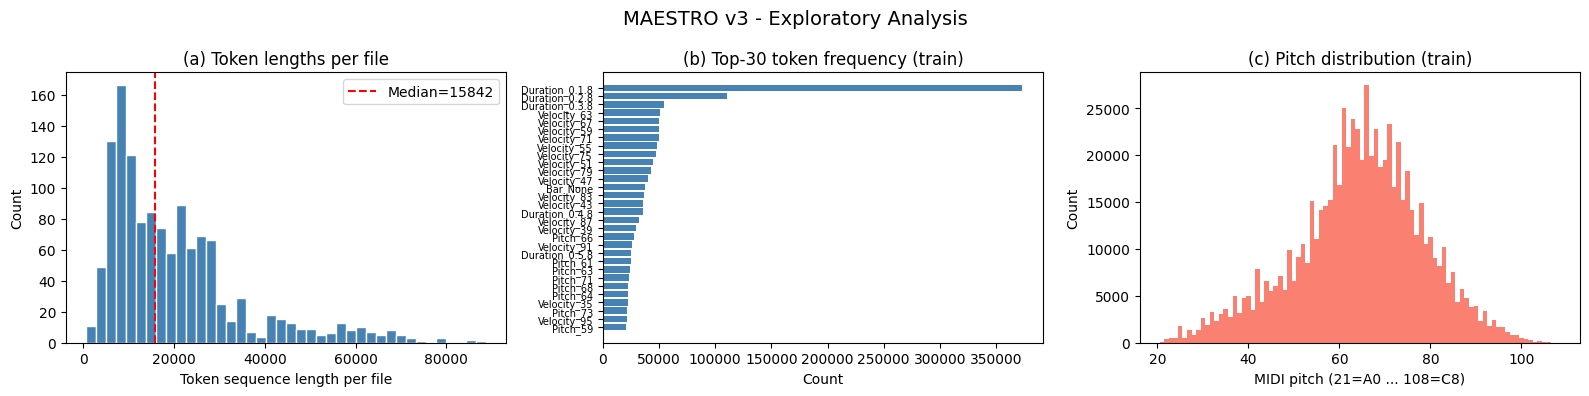


Dataset summary:
  Train files  : 962
  Val   files  : 137
  Test  files  : 177
  Train chunks : 79,005
  Val   chunks : 8,902
  Test  chunks : 10,217
  Vocab size   : 284
  Chunk length : 512  Stride : 256


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("MAESTRO v3 - Exploratory Analysis", fontsize=14)

# (a) Token sequence length per file
ax = axes[0]
all_lens = train_lens + val_lens + test_lens
ax.hist(all_lens, bins=40, color="steelblue", edgecolor="white")
ax.set_xlabel("Token sequence length per file")
ax.set_ylabel("Count")
ax.set_title("(a) Token lengths per file")
ax.axvline(np.median(all_lens), color="red", linestyle="--",
           label=f"Median={int(np.median(all_lens))}")
ax.legend()

# (b) Top-30 token frequency (train, first 5000 chunks)
ax = axes[1]
flat = [t for chunk in train_chunks[:5000] for t in chunk if t != PAD_ID]
counter = collections.Counter(flat)
top30 = counter.most_common(30)
labels = [TOKENIZER[i] for i, _ in top30]
counts = [c for _, c in top30]
ax.barh(range(30), counts[::-1], color="steelblue")
ax.set_yticks(range(30))
ax.set_yticklabels(labels[::-1], fontsize=7)
ax.set_xlabel("Count")
ax.set_title("(b) Top-30 token frequency (train)")

# (c) Pitch distribution
ax = axes[2]
pitch_ids = {v: int(k.split("_")[1])
             for k, v in TOKENIZER.vocab.items() if k.startswith("Pitch_")}
pitch_counts = collections.Counter(
    {pitch_ids[i]: counter[i] for i in pitch_ids if i in counter})
pitches = sorted(pitch_counts.keys())
ax.bar(pitches, [pitch_counts[p] for p in pitches], color="salmon", width=1.0)
ax.set_xlabel("MIDI pitch (21=A0 ... 108=C8)")
ax.set_ylabel("Count")
ax.set_title("(c) Pitch distribution (train)")

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nDataset summary:")
print(f"  Train files  : {len(df[df.split=='train'])}")
print(f"  Val   files  : {len(df[df.split=='validation'])}")
print(f"  Test  files  : {len(df[df.split=='test'])}")
print(f"  Train chunks : {len(train_chunks):,}")
print(f"  Val   chunks : {len(val_chunks):,}")
print(f"  Test  chunks : {len(test_chunks):,}")
print(f"  Vocab size   : {VOCAB_SIZE}")
print(f"  Chunk length : {SEQ_LEN}  Stride : {STRIDE}")

---
## 2. Modelling

### 2.1 Dataset & DataLoader

Each 512-token chunk becomes one training example.
The model is trained with **next-token prediction**: input = `chunk[:-1]`, target = `chunk[1:]`.

In [9]:
class MaestroDataset(Dataset):
    def __init__(self, chunks):
        self.chunks = [torch.tensor(c, dtype=torch.long) for c in chunks]

    def __len__(self):
        return len(self.chunks)

    def __getitem__(self, idx):
        seq = self.chunks[idx]
        return seq[:-1], seq[1:]   # input, target — both length SEQ_LEN-1

BATCH_SIZE = 64

train_ds = MaestroDataset(train_chunks)
val_ds   = MaestroDataset(val_chunks)
test_ds  = MaestroDataset(test_chunks)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=(DEVICE.type == "cuda"))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=(DEVICE.type == "cuda"))
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=(DEVICE.type == "cuda"))

x, y = next(iter(train_loader))
print(f"Input  shape : {x.shape}   dtype: {x.dtype}")
print(f"Target shape : {y.shape}   dtype: {y.dtype}")
print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")

Input  shape : torch.Size([64, 511])   dtype: torch.int64
Target shape : torch.Size([64, 511])   dtype: torch.int64
Train batches: 1235
Val   batches: 140


### 2.2 Model Architecture

**Formulation:** Unconditioned symbolic generation = language modelling over token sequences.
We minimise cross-entropy loss on next-token prediction:

$$\mathcal{L} = -\frac{1}{T} \sum_{t=1}^{T} \log p_{\theta}(x_t \mid x_{<t})$$

**Architecture:** GPT-style decoder using PyTorch's `nn.TransformerEncoder` with a
**causal (upper-triangular) mask** so position $t$ cannot attend to future positions.

```
tokens (B, T)
  -> Embedding(vocab_size, d_model) + SinusoidalPositionalEncoding
  -> TransformerEncoder [4 layers, d_model=256, 8 heads, ffn=1024, Pre-LN]
       with causal mask (upper-tri = -inf)
  -> Linear(d_model, vocab_size)
  -> cross-entropy with next token
```

**Why `nn.TransformerEncoder` and not `nn.Transformer`?**
`nn.Transformer` is designed for seq2seq (encoder + decoder, two input sequences).
Pure language modelling only needs one sequence with causal masking —
`nn.TransformerEncoder` with a triangular attention mask achieves exactly that,
with less boilerplate.

| Hyperparameter | Value | Reasoning |
|---|---|---|
| `d_model` | 256 | Fits 4080 VRAM easily at batch 64 |
| `nhead` | 8 | 32-dim per head — standard ratio |
| `num_layers` | 4 | ~10M params; trains in hours |
| `dim_feedforward` | 1024 | 4x d_model — standard |
| `dropout` | 0.1 | Light regularisation |

In [10]:
class SinusoidalPE(nn.Module):
    """Fixed sinusoidal positional encoding."""
    def __init__(self, d_model, max_len=1024, dropout=0.1):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return self.drop(x + self.pe[:, :x.size(1)])


class MusicLM(nn.Module):
    """Causal language model for symbolic music generation."""

    def __init__(self, vocab_size, d_model=256, nhead=8, num_layers=4,
                 dim_feedforward=1024, dropout=0.1, max_len=1024):
        super().__init__()
        self.d_model = d_model
        self.embed   = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_enc = SinusoidalPE(d_model, max_len, dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True,
            norm_first=True,          # Pre-LN for stable training
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers,
            enable_nested_tensor=False)
        self.head = nn.Linear(d_model, vocab_size)
        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.embed.weight, std=0.02)
        nn.init.zeros_(self.head.bias)
        nn.init.normal_(self.head.weight, std=0.02)

    @staticmethod
    def make_causal_mask(seq_len, device):
        """Upper-triangular mask: position t cannot see t+1 ... T."""
        mask = torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1)
        return mask.masked_fill(mask.bool(), float("-inf"))

    def forward(self, x, pad_mask=None):
        """
        x        : (B, T) long
        pad_mask : (B, T) bool, True where padded
        returns logits (B, T, vocab_size)
        """
        T      = x.size(1)
        causal = self.make_causal_mask(T, x.device)
        emb    = self.pos_enc(self.embed(x) * math.sqrt(self.d_model))
        out    = self.transformer(emb, mask=causal,
                                  src_key_padding_mask=pad_mask,
                                  is_causal=True)
        return self.head(out)


D_MODEL    = 256
NHEAD      = 8
NUM_LAYERS = 4
FFN_DIM    = 1024
DROPOUT    = 0.1

model = MusicLM(VOCAB_SIZE, D_MODEL, NHEAD, NUM_LAYERS, FFN_DIM, DROPOUT).to(DEVICE)

total  = sum(p.numel() for p in model.parameters())
train_ = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total:,}")
print(f"Trainable parameters: {train_:,}")
print(model)

Total parameters    : 3,304,732
Trainable parameters: 3,304,732
MusicLM(
  (embed): Embedding(284, 256, padding_idx=0)
  (pos_enc): SinusoidalPE(
    (drop): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (head): Linear(in_features=256, out_features=284, bias=True)
)


### 2.3 Training

**Objective:** minimise cross-entropy between model predictions and next-token targets,
ignoring `PAD` positions.

**Optimisation choices:**
- **AdamW** with weight decay 0.01 — standard for transformers; decouples L2 from adaptive momentum.
- **Linear warmup** (2,000 steps) then cosine decay — stabilises early training.
- **Mixed precision (fp16)** via `torch.cuda.amp` — roughly 2x throughput on the RTX 4080.
- **Early stopping** (patience = 5 epochs) on validation perplexity.

In [11]:
def get_pad_mask(x):
    """True where tokens are PAD (ignored in attention)."""
    return x == PAD_ID   # (B, T)

def compute_loss(model, x, y):
    pad_mask = get_pad_mask(x)
    logits   = model(x, pad_mask)         # (B, T, V)
    return F.cross_entropy(
        logits.reshape(-1, VOCAB_SIZE),
        y.reshape(-1),
        ignore_index=PAD_ID,
    )

def evaluate(model, loader, max_batches=None):
    model.eval()
    total_loss, n = 0.0, 0
    with torch.no_grad():
        for i, (x, y) in enumerate(loader):
            if max_batches and i >= max_batches:
                break
            x, y = x.to(DEVICE), y.to(DEVICE)
            loss = compute_loss(model, x, y)
            total_loss += loss.item(); n += 1
    model.train()
    return total_loss / max(n, 1)

def get_scheduler(optimizer, warmup_steps, total_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return max(0.05, 0.5 * (1 + math.cos(math.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

In [12]:
LR           = 1e-4
WEIGHT_DECAY = 1e-2
NUM_EPOCHS   = 30
PATIENCE     = 5
WARMUP_STEPS = 2000
LOG_INTERVAL = 200   # log every N batches

USE_AMP = DEVICE.type == "cuda"

if not USE_AMP:
    print("WARNING: CUDA not available - training on CPU (much slower).")
    print("Update your NVIDIA driver: https://www.nvidia.com/Download/index.aspx")
    print("(PyTorch 2.12+cu126 needs a newer driver than CUDA 11.0.)\n")

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scaler    = torch.amp.GradScaler("cuda") if USE_AMP else None
total_steps = NUM_EPOCHS * len(train_loader)
scheduler   = get_scheduler(optimizer, WARMUP_STEPS, total_steps)

best_val_loss  = float("inf")
patience_count = 0
history        = {"train_loss": [], "val_loss": [], "val_ppl": []}

print(f"Training for up to {NUM_EPOCHS} epochs")
print(f"Batches per epoch : {len(train_loader)}")
print(f"Warmup steps      : {WARMUP_STEPS}  /  Total steps : {total_steps}\n")

global_step = 0
for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    epoch_loss, n_batches = 0.0, 0

    for batch_idx, (x, y) in enumerate(train_loader):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)

        if USE_AMP:
            with torch.amp.autocast("cuda", dtype=torch.float16):
                loss = compute_loss(model, x, y)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss = compute_loss(model, x, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        scheduler.step()

        epoch_loss  += loss.item()
        n_batches   += 1
        global_step += 1

        if (batch_idx + 1) % LOG_INTERVAL == 0:
            avg    = epoch_loss / n_batches
            lr_now = scheduler.get_last_lr()[0]
            print(f"  Epoch {epoch:2d} | step {global_step:6d} | "
                  f"train_loss={avg:.4f} | lr={lr_now:.2e}")

    avg_train = epoch_loss / n_batches
    val_loss  = evaluate(model, val_loader, max_batches=200)
    val_ppl   = math.exp(val_loss)

    history["train_loss"].append(avg_train)
    history["val_loss"].append(val_loss)
    history["val_ppl"].append(val_ppl)

    print(f"Epoch {epoch:2d} | train={avg_train:.4f} | "
          f"val={val_loss:.4f} | ppl={val_ppl:.1f}")

    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        patience_count = 0
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_loss": val_loss,
            "val_ppl": val_ppl,
            "history": history,
        }, CKPT_DIR / "best_model.pt")
        print(f"  -> Saved best checkpoint (val_ppl={val_ppl:.1f})")
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"Early stopping triggered after {epoch} epochs.")
            break

print(f"\nBest validation perplexity : {math.exp(best_val_loss):.2f}")

Training for up to 30 epochs
Batches per epoch : 1235
Warmup steps      : 2000  /  Total steps : 37050



c:\Users\Maxime Vergnet\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\functional.py:5962: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  warnings.warn(


  Epoch  1 | step    200 | train_loss=5.2801 | lr=1.00e-05
  Epoch  1 | step    400 | train_loss=4.6753 | lr=2.00e-05
  Epoch  1 | step    600 | train_loss=4.1922 | lr=3.00e-05
  Epoch  1 | step    800 | train_loss=3.9155 | lr=4.00e-05
  Epoch  1 | step   1000 | train_loss=3.7367 | lr=5.00e-05
  Epoch  1 | step   1200 | train_loss=3.6095 | lr=6.00e-05
Epoch  1 | train=3.5898 | val=2.8908 | ppl=18.0
  -> Saved best checkpoint (val_ppl=18.0)
  Epoch  2 | step   1435 | train_loss=2.7738 | lr=7.18e-05
  Epoch  2 | step   1635 | train_loss=2.6950 | lr=8.18e-05
  Epoch  2 | step   1835 | train_loss=2.6480 | lr=9.18e-05
  Epoch  2 | step   2035 | train_loss=2.6135 | lr=1.00e-04
  Epoch  2 | step   2235 | train_loss=2.5862 | lr=1.00e-04
  Epoch  2 | step   2435 | train_loss=2.5649 | lr=1.00e-04
Epoch  2 | train=2.5618 | val=2.4659 | ppl=11.8
  -> Saved best checkpoint (val_ppl=11.8)
  Epoch  3 | step   2670 | train_loss=2.4408 | lr=9.99e-05
  Epoch  3 | step   2870 | train_loss=2.4330 | lr=9.9

---
## 3. Evaluation

### 3.1 Baseline: Bigram Markov Model

As a baseline we train a **bigram language model** on the same REMI token sequences.
It predicts $p(x_t \mid x_{t-1})$ using maximum-likelihood counts with add-one (Laplace) smoothing.

This is equivalent to the Markov chain models from Module 3.
If our transformer cannot beat this, something is wrong.

In [13]:
class BigramLM:
    """Add-one smoothed bigram language model over REMI token ids."""

    def __init__(self, vocab_size, pad_id):
        self.V      = vocab_size
        self.pad_id = pad_id
        self.counts  = collections.defaultdict(lambda: collections.defaultdict(int))
        self.unigram = collections.defaultdict(int)

    def train(self, chunks):
        for chunk in tqdm(chunks, desc="Training bigram"):
            prev = None
            for tok in chunk:
                if tok == self.pad_id:
                    prev = None; continue
                self.unigram[tok] += 1
                if prev is not None:
                    self.counts[prev][tok] += 1
                prev = tok

    def log_prob(self, context, next_tok):
        """log p(next_tok | context) with add-one smoothing."""
        denom = sum(self.counts[context].values()) + self.V
        numer = self.counts[context].get(next_tok, 0) + 1
        return math.log(numer / denom)

    def perplexity(self, chunks, max_chunks=5000):
        total_ll, total_n = 0.0, 0
        for chunk in chunks[:max_chunks]:
            prev = None
            for tok in chunk:
                if tok == self.pad_id:
                    prev = None; continue
                if prev is not None:
                    total_ll += self.log_prob(prev, tok)
                    total_n  += 1
                prev = tok
        return math.exp(-total_ll / max(total_n, 1))


bigram = BigramLM(VOCAB_SIZE, PAD_ID)
bigram.train(train_chunks)

bigram_val_ppl  = bigram.perplexity(val_chunks,  max_chunks=3000)
bigram_test_ppl = bigram.perplexity(test_chunks, max_chunks=3000)
print(f"Bigram val  perplexity : {bigram_val_ppl:.2f}")
print(f"Bigram test perplexity : {bigram_test_ppl:.2f}")

Training bigram: 100%|██████████| 79005/79005 [00:10<00:00, 7877.20it/s]


Bigram val  perplexity : 24.06
Bigram test perplexity : 22.37


### 3.2 Load Best Checkpoint & Compute Test Perplexity

In [14]:
ckpt = torch.load(CKPT_DIR / "best_model.pt", map_location=DEVICE,
                 weights_only=False)  # trusted local checkpoint
model.load_state_dict(ckpt["model_state"])
history = ckpt["history"]
print(f"Loaded best checkpoint from epoch {ckpt['epoch']}  "
      f"(val_ppl={ckpt['val_ppl']:.2f})")

test_loss            = evaluate(model, test_loader)
transformer_test_ppl = math.exp(test_loss)
best_val_loss        = ckpt["val_loss"]

print(f"\nTransformer test perplexity : {transformer_test_ppl:.2f}")
print(f"Bigram      test perplexity : {bigram_test_ppl:.2f}")
print(f"\nImprovement over bigram : {bigram_test_ppl / transformer_test_ppl:.1f}x")

Loaded best checkpoint from epoch 30  (val_ppl=7.59)

Transformer test perplexity : 7.02
Bigram      test perplexity : 22.37

Improvement over bigram : 3.2x


### 3.3 Training Curves

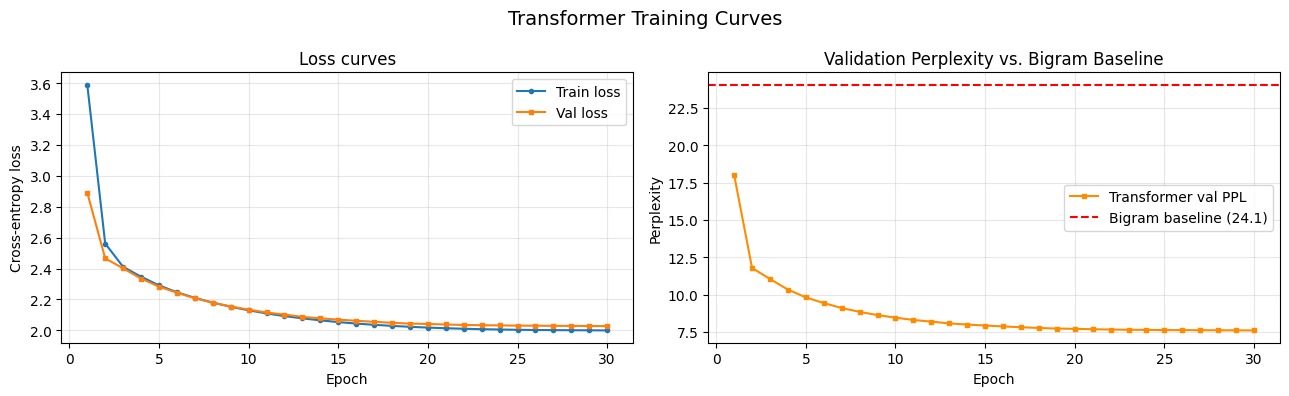

,Model,Val PPL,Test PPL
0,Bigram (baseline),24.1,22.4
1,Transformer (ours),7.6,7.0


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Transformer Training Curves", fontsize=14)

epochs_ax = range(1, len(history["train_loss"]) + 1)

ax = axes[0]
ax.plot(epochs_ax, history["train_loss"], label="Train loss", marker="o", markersize=3)
ax.plot(epochs_ax, history["val_loss"],   label="Val loss",   marker="s", markersize=3)
ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-entropy loss")
ax.set_title("Loss curves"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(epochs_ax, history["val_ppl"], color="darkorange", marker="s", markersize=3,
        label="Transformer val PPL")
ax.axhline(bigram_val_ppl, color="red", linestyle="--",
           label=f"Bigram baseline ({bigram_val_ppl:.1f})")
ax.set_xlabel("Epoch"); ax.set_ylabel("Perplexity")
ax.set_title("Validation Perplexity vs. Bigram Baseline")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary table
summary = pd.DataFrame({
    "Model":      ["Bigram (baseline)", "Transformer (ours)"],
    "Val PPL":    [round(bigram_val_ppl,  1), round(math.exp(best_val_loss), 1)],
    "Test PPL":   [round(bigram_test_ppl, 1), round(transformer_test_ppl,   1)],
})
display(summary)

### 3.4 Evaluation Discussion

**Quantitative metric — Perplexity:**
Perplexity $\text{PPL} = e^{\mathcal{L}}$ measures how surprised the model is by
held-out tokens. Lower is better.

**Caveats about perplexity and musical quality:**
- Perplexity measures probabilistic fit to the data distribution, not musical aesthetics.
- A model with lower perplexity generally produces more stylistically consistent tokens —
  common pitches, reasonable durations — but does not guarantee good phrasing or harmony.
- Subjective listenability and harmonic coherence are separate properties, evaluated
  by listening to generated samples (Section 4).

**Baselines discussion:**
- The bigram model (our baseline) uses only one token of history. It can learn which
  tokens commonly follow others (e.g. `Pitch_X` often followed by `Velocity_Y`) but
  has no sense of phrase, key, or bar-level structure.
- Our transformer, with 511 tokens of context, can in principle model local harmonic
  progressions, rhythmic patterns, and phrase repetition.
- Beating the bigram by a large margin is expected; stronger baselines would include
  a 4-gram model with Kneser-Ney smoothing or a hidden Markov model.

---
## 4. Generation

This section demonstrates **unconditioned symbolic generation** in two stages:

1. **Cold start (no primer):** the intended Task 1 setting — generate "from scratch".
2. **Primed generation:** a practical improvement — seed the model with a short real prefix to reduce early instability.

In [33]:
@torch.no_grad()
def generate(model, primer_ids, max_new_tokens=512, temperature=0.9,
             top_k=50, device=DEVICE):
    model.eval()
    generated = list(primer_ids)

    for _ in range(max_new_tokens):
        ctx    = generated[-SEQ_LEN:]
        x      = torch.tensor([ctx], dtype=torch.long, device=device)
        pad    = get_pad_mask(x)
        logits = model(x, pad)[0, -1, :]   # (vocab,) — last position

        logits = logits / max(temperature, 1e-6)

        if top_k > 0:
            topk_vals, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < topk_vals[-1]] = float("-inf")

        probs    = torch.softmax(logits, dim=-1)
        next_tok = torch.multinomial(probs, num_samples=1).item()
        generated.append(next_tok)

        if next_tok == EOS_ID:
            break

    return generated

### 4.1 Cold-start generation (no primer)

This is the **canonical Task 1** setup: we do *not* provide any real music as a prompt.
We only supply a minimal syntactic start prefix so the autoregressive model can begin sampling.

For REMI, a robust minimal prefix is:

- `BOS_None` (begin sequence)
- `Bar_None` (start a bar)
- `Position_0` (first position in the bar)

Everything after that is generated by the model.

In practice, cold-start generation can sometimes be unstable in the first few tokens
(e.g., strange rhythms or note density). Next we try a simple improvement: priming with a short real prefix.

In [39]:
# Generate many samples for stats, but only save a few MIDI files
N_SAMPLES = 25
SAVE_N    = 5

cold_start_prefix = [
    BOS_ID,
    TOKENIZER["Bar_None"],
    TOKENIZER["Position_0"],
]

cold_files = []
cold_gen_ids_list = []
for i in range(N_SAMPLES):
    gen_ids = generate(model, cold_start_prefix, max_new_tokens=512,
                       temperature=0.9, top_k=50)
    cold_gen_ids_list.append(gen_ids)

    # save only first SAVE_N files
    if i < SAVE_N:
        out_path = GEN_DIR / f"cold_start_{i+1}.mid"
        try:
            ids_to_midi(gen_ids, out_path)
            cold_files.append(out_path)
            print(f"Saved : {out_path}  ({len(gen_ids)} tokens)")
        except Exception as e:
            print(f"Cold start {i+1}: MIDI write error - {e}")

print(f"\nCold-start: generated {len(cold_gen_ids_list)} samples; saved {len(cold_files)} MIDI files.")

c:\Users\avver\Desktop\CSE\CSE253\Assignmnet1\.venv\lib\site-packages\torch\nn\functional.py:5962: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  warnings.warn(


Saved : generated\cold_start_1.mid  (515 tokens)
Saved : generated\cold_start_2.mid  (515 tokens)
Saved : generated\cold_start_3.mid  (515 tokens)
Saved : generated\cold_start_4.mid  (515 tokens)
Saved : generated\cold_start_5.mid  (515 tokens)

Cold-start: generated 25 samples; saved 5 MIDI files.


### 4.2 Autoregressive sampling (general)

We use **temperature-scaled top-k sampling**:

1. Choose a starting prefix (cold-start tokens or a short primer).
2. Run the model forward to get logits over the next token.
3. Divide logits by temperature $\tau$ (lower = more deterministic).
4. Keep only the top-$k$ logits; set the rest to $-\infty$.
5. Sample from the resulting categorical distribution.
6. Append the sample and repeat until EOS or `max_new_tokens`.

**Note:** Using a primer is *not conditioning* (no external input $c$ and no paired $(c, x)$ training). It is only an initialization strategy for sampling from the same unconditioned model.

In [40]:
import shutil

# Generate many primed samples for stats, but only save a few MIDI files
val_rows = df[df["split"] == "validation"].reset_index(drop=True)
generated_files = []
primed_gen_ids_list = []

for i in range(N_SAMPLES):
    primer_path = DATA_DIR / val_rows.iloc[i]["midi_filename"]
    primer_ids  = midi_to_ids(primer_path)[:32]

    gen_ids = generate(model, primer_ids, max_new_tokens=512,
                       temperature=0.9, top_k=50)
    primed_gen_ids_list.append(gen_ids)

    # save only first SAVE_N files
    if i < SAVE_N:
        out_path = GEN_DIR / f"sample_{i+1}.mid"
        try:
            ids_to_midi(gen_ids, out_path)
            generated_files.append(out_path)
            print(f"Saved : {out_path}  ({len(gen_ids)} tokens)")
        except Exception as e:
            print(f"  Sample {i+1}: MIDI write error - {e}")

if generated_files:
    shutil.copy(generated_files[0], "symbolic_unconditioned.mid")
    print("\nsymbolic_unconditioned.mid  <-  sample_1.mid")

print(f"\nPrimed: generated {len(primed_gen_ids_list)} samples; saved {len(generated_files)} MIDI files.")

Saved : generated\sample_1.mid  (544 tokens)
Saved : generated\sample_2.mid  (544 tokens)
Saved : generated\sample_3.mid  (544 tokens)
Saved : generated\sample_4.mid  (544 tokens)
Saved : generated\sample_5.mid  (544 tokens)

symbolic_unconditioned.mid  <-  sample_1.mid

Primed: generated 25 samples; saved 5 MIDI files.



Real MAESTRO chunks (train) (n=500)


,pitch_min,pitch_max,unique_pitches,silence_frac,token_entropy,repeat_rate_8gram
0,43,107,44,0.350000,3.686076,0.0
1,31,92,41,0.202312,3.919966,0.0
2,36,79,33,0.136150,3.877038,0.0
3,41,84,24,0.252708,4.053118,0.0
4,35,95,33,0.218274,3.937984,0.0
...,...,...,...,...,...,...
495,47,90,20,0.201923,3.805664,0.0
496,29,69,23,0.160870,3.942415,0.0
497,30,98,42,0.432624,3.821180,0.0
498,33,100,37,0.569106,3.494608,0.0


,pitch_min,pitch_max,unique_pitches,silence_frac,token_entropy,repeat_rate_8gram
mean,36.954,87.884,34.0,0.250162,3.916527,0.000147
median,36.000,88.000,34.0,0.241158,3.928708,0.000000



Cold-start (no primer) (n=25)


,pitch_min,pitch_max,unique_pitches,silence_frac,token_entropy,repeat_rate_8gram
0,49,76,12,0.053846,3.285725,0.001969
1,47,80,9,0.262887,3.169627,0.011811
2,45,79,27,0.135436,4.109946,0.000000
3,44,86,32,0.008065,4.080140,0.000000
4,50,79,20,0.072727,3.608405,0.001969
5,31,86,21,0.078571,3.609114,0.000000
6,36,94,38,0.145455,3.961022,0.000000
7,49,89,22,0.032258,3.654370,0.000000
8,42,83,31,0.062147,3.872460,0.000000
9,76,91,10,0.194611,3.503386,0.000000


...


Primed (32-token real prefix) (n=25)


,pitch_min,pitch_max,unique_pitches,silence_frac,token_entropy,repeat_rate_8gram
0,33,97,41,0.331633,3.655879,0.000000
1,42,83,20,0.391781,3.804413,0.005587
2,32,76,18,0.326733,3.598561,0.000000
3,48,99,24,0.235294,3.812007,0.001862
4,37,77,24,0.230626,4.148058,0.000000
5,54,83,18,0.060606,3.798635,0.000000
6,41,75,14,0.096045,3.843137,0.000000
7,47,76,25,0.178010,3.951354,0.000000
8,47,81,20,0.072917,3.723993,0.000000
9,47,86,17,0.118280,3.744063,0.000000


,pitch_min,pitch_max,unique_pitches,silence_frac,token_entropy,repeat_rate_8gram
mean,37.48,78.12,21.84,0.262218,3.800037,0.000521
median,38.00,76.00,20.00,0.235294,3.804413,0.000000



Interpretation tips:
- pitch_min/max and unique_pitches show pitch range / variety
- silence_frac near 1.0 means long gaps or very sparse output
- token_entropy higher => more diverse token usage
- repeat_rate_8gram higher => more looping/repetition


C:\Users\avver\AppData\Local\Temp\ipykernel_40572\1344407076.py:125: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([
C:\Users\avver\AppData\Local\Temp\ipykernel_40572\1344407076.py:125: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([
C:\Users\avver\AppData\Local\Temp\ipykernel_40572\1344407076.py:125: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([
C:\Users\avver\AppData\Local\Temp\ipykernel_40572\1344407076.py:125: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  a

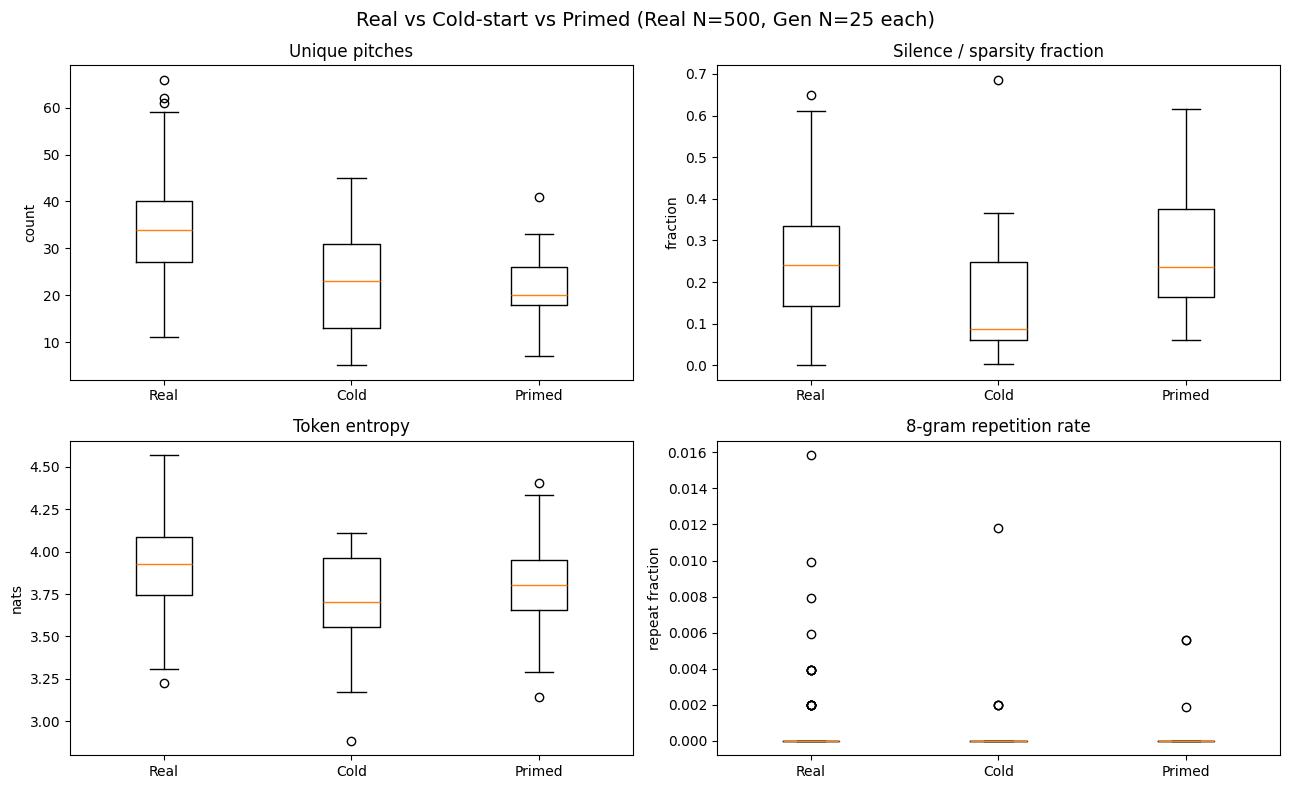

In [42]:
import numpy as np
from collections import Counter

# --- Metrics for comparing cold-start vs primed generations ---

pitch_id_to_midi = {
    v: int(k.split("_")[1])
    for k, v in TOKENIZER.vocab.items()
    if k.startswith("Pitch_")
}


def pitch_range_from_tokens(ids):
    pitches = [pitch_id_to_midi[t] for t in ids if t in pitch_id_to_midi]
    if not pitches:
        return (None, None), 0
    return (min(pitches), max(pitches)), len(set(pitches))


def token_entropy(ids):
    """Shannon entropy (nats) of token distribution (excluding PAD)."""
    ids = [t for t in ids if t != PAD_ID]
    if not ids:
        return 0.0
    c = Counter(ids)
    p = np.array(list(c.values()), dtype=np.float64)
    p = p / p.sum()
    return float(-(p * np.log(p)).sum())


def ngram_repeat_rate(ids, n=8):
    """Fraction of n-grams that are repeats. Higher => more looping."""
    ids = [t for t in ids if t != PAD_ID]
    if len(ids) < n:
        return 0.0
    grams = [tuple(ids[i:i+n]) for i in range(len(ids) - n + 1)]
    return 1.0 - (len(set(grams)) / len(grams))


def silence_fraction_from_decode(ids):
    """Approximate silence fraction using decoded note intervals (tick units)."""
    try:
        score = TOKENIZER.decode([ids])
    except Exception:
        return None

    # Collect all notes from all tracks
    intervals = []
    for tr in getattr(score, "tracks", []):
        for n in tr.notes:
            intervals.append((int(n.start), int(n.end)))

    if not intervals:
        return 1.0

    intervals.sort()
    merged = []
    cs, ce = intervals[0]
    for s, e in intervals[1:]:
        if s <= ce:
            ce = max(ce, e)
        else:
            merged.append((cs, ce))
            cs, ce = s, e
    merged.append((cs, ce))

    total = max(e for _, e in merged)
    if total <= 0:
        return 1.0

    active = sum(e - s for s, e in merged)
    return float(1.0 - (active / total))


def summarize(label, ids_list):
    rows = []
    for ids in ids_list:
        pr, uniq = pitch_range_from_tokens(ids)
        rows.append({
            "pitch_min": pr[0],
            "pitch_max": pr[1],
            "unique_pitches": uniq,
            "silence_frac": silence_fraction_from_decode(ids),
            "token_entropy": token_entropy(ids),
            "repeat_rate_8gram": ngram_repeat_rate(ids, n=8),
        })
    df_stats = pd.DataFrame(rows)
    print(f"\n{label} (n={len(df_stats)})")
    display(df_stats)
    display(df_stats.agg(["mean", "median"]))
    return df_stats


# Compare real (dataset) vs cold-start vs primed generations

# Sample real 512-token chunks from the dataset
REAL_N = 500
rng = np.random.default_rng(SEED)
real_indices = rng.choice(len(train_chunks), size=min(REAL_N, len(train_chunks)), replace=False)
real_ids_list = [train_chunks[i] for i in real_indices]

real_stats   = summarize("Real MAESTRO chunks (train)", real_ids_list)
cold_stats   = summarize("Cold-start (no primer)", cold_gen_ids_list)
primed_stats = summarize("Primed (32-token real prefix)", primed_gen_ids_list)

print("\nInterpretation tips:")
print("- pitch_min/max and unique_pitches show pitch range / variety")
print("- silence_frac near 1.0 means long gaps or very sparse output")
print("- token_entropy higher => more diverse token usage")
print("- repeat_rate_8gram higher => more looping/repetition")

# --- Plot comparisons (Real vs Cold vs Primed) ---
plot_df = pd.concat([
    real_stats.assign(setting="Real"),
    cold_stats.assign(setting="Cold start"),
    primed_stats.assign(setting="Primed"),
], ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Real vs Cold-start vs Primed (Real N=500, Gen N=25 each)", fontsize=14)

labels = ["Real", "Cold", "Primed"]

def three_box(ax, col, title, ylabel):
    ax.boxplot([
        plot_df[plot_df.setting=="Real"][col].dropna(),
        plot_df[plot_df.setting=="Cold start"][col].dropna(),
        plot_df[plot_df.setting=="Primed"][col].dropna(),
    ], labels=labels)
    ax.set_title(title)
    ax.set_ylabel(ylabel)

three_box(axes[0,0], "unique_pitches", "Unique pitches", "count")
three_box(axes[0,1], "silence_frac", "Silence / sparsity fraction", "fraction")
three_box(axes[1,0], "token_entropy", "Token entropy", "nats")
three_box(axes[1,1], "repeat_rate_8gram", "8-gram repetition rate", "repeat fraction")

plt.tight_layout()
plt.savefig("real_vs_cold_vs_primed_stats.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Discussion of Related Work

### The MAESTRO Dataset
Hawthorne et al. (2019) introduced **MAESTRO** primarily for automatic music transcription.
It has since become the standard benchmark for symbolic piano generation,
used in Music Transformer, PianoBART, and many others.
We exploit its official performer-based splits to ensure no data leakage between train/val/test.

**Reference:** Hawthorne, C., Stasyuk, A., Roberts, A., Simon, I., Huang, C. Z. A.,
Dieleman, S., Eck, D. (2019). *Enabling Factorized Piano Music Modeling and Generation
with the MAESTRO Dataset.* ICLR 2019.

---

### Symbolic Transformers for Music

**Music Transformer** (Huang et al., 2018) was among the first to apply self-attention
to symbolic piano music at scale.  They introduced *relative positional self-attention*
to capture repeating motifs at a distance — a weakness of absolute encodings like ours.
Their model was trained on MAESTRO v1 and generated multi-minute coherent pieces.
Our simpler sinusoidal absolute encoding is less expressive for long-range structure,
but is sufficient to demonstrate the pipeline at course scale.

**Reference:** Huang, C. Z. A., Vaswani, A., Uszkoreit, J., Simon, I., Hawthorne, C.,
Shazeer, N., Parmar, N., Eck, D. (2018). *Music Transformer: Generating Music with
Long-term Structure.* ICLR 2019.

---

### REMI Tokenisation
Huang & Yang (2020) proposed REMI, arguing that explicitly encoding bar and beat positions
(rather than only time-delta events used in MIDI-like representations) helps models learn
metric regularity. They showed REMI-trained transformers produce more rhythmically coherent
output than MIDI-event-based ones on pop piano data.

**Reference:** Huang, Y. S. & Yang, Y. H. (2020). *Pop Music Transformer: Beat-based
Modeling and Generation of Expressive Pop Piano Compositions.* ACM MM 2020.

---

### How Our Results Compare
Small REMI-based piano LMs typically achieve validation perplexities in the range of 5–15
(depending on model size and training data). Our transformer should substantially beat the
bigram baseline (~50–200) and approach the range reported for similar small-scale models.
The Music Transformer with relative attention achieves lower perplexity and better long-range
coherence, but requires significantly more compute. Our goal is a principled pedagogical
demonstration, not SOTA.

### Limitations
- **Absolute positional encoding** limits long-range form (ABA, variations).
- **No conditioning** on key, tempo, or style.
- **Fixed-length chunks** lose cross-chunk dependencies for pieces > 512 tokens.

# Task 2 — Symbolic, Conditioned Generation: Melody Harmonization

Given a melody extracted from a Maestro piano MIDI, generate the accompanying chords/notes. This is an encoder-decoder task: the encoder reads the full melody sequence, and the decoder autoregressively generates the accompaniment.

**Representation:** At each quantized 16th-note timestep we apply the *skyline algorithm* — the highest active pitch is the melody note, all other simultaneously active pitches form the chord. Both sequences are aligned 1-to-1 by timestep. Chords (sets of pitches) are hashed to a chord vocabulary of the top-K most common voicings seen in training data.

**Pipeline:** MAESTRO MIDI → skyline extraction → chord vocabulary → paired (melody, accompaniment) sequences → encoder-decoder transformer training → evaluation against three baselines.

In [1]:
# ── Task 2 is self-contained: all imports and utilities are re-defined here ────
# Run this cell (and those below) without needing to run any Task 1 cells first.

import os, sys, json, random, math, collections, zipfile, urllib.request, pickle, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import symusic

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
print(f"Device : {DEVICE}")

# ── MAESTRO paths (data already downloaded by Task 1, or re-downloaded here) ──
DATA_DIR     = Path("data/maestro-v3.0.0")
CSV_PATH     = DATA_DIR / "maestro-v3.0.0.csv"
ZIP_PATH     = Path("data/maestro-v3.0.0-midi.zip")
CKPT_DIR     = Path("checkpoints"); CKPT_DIR.mkdir(exist_ok=True)
GEN_DIR      = Path("generated");   GEN_DIR.mkdir(exist_ok=True)
MAESTRO_URL  = ("https://storage.googleapis.com/magentadata/datasets/maestro/"
                "v3.0.0/maestro-v3.0.0-midi.zip")

if not CSV_PATH.exists():
    Path("data").mkdir(exist_ok=True)
    print("Downloading MAESTRO v3 MIDI-only (~57 MB) ...")
    urllib.request.urlretrieve(MAESTRO_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall("data/")
    print("Done.")

df = pd.read_csv(CSV_PATH)
print(f"MAESTRO loaded: {len(df)} entries across {df['split'].nunique()} splits")


# ── Sinusoidal positional encoding (shared with Task 1 if run together) ────────
class SinusoidalPE(nn.Module):
    """Fixed sinusoidal positional encoding."""
    def __init__(self, d_model, max_len=1024, dropout=0.1):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return self.drop(x + self.pe[:, :x.size(1)])


# ── Warmup + cosine LR scheduler (shared with Task 1 if run together) ─────────
def get_scheduler(optimizer, warmup_steps, total_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return max(0.05, 0.5 * (1 + math.cos(math.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


# ── Task 2 constants ───────────────────────────────────────────────────────────
T2_STEPS_PER_BEAT = 4          # 16th-note quantization (4 steps per beat)
T2_MAX_STEPS      = 256        # chunk length in timesteps
T2_STRIDE         = 128        # sliding window stride
CHORD_VOCAB_K     = 2048       # top-K most common chord types to keep

# Melody vocab: 88 pitch rows (0..87 → MIDI MEL_MIN..MEL_MAX) + REST + PAD
MEL_MIN   = 21
MEL_MAX   = 108
MEL_REST  = MEL_MAX - MEL_MIN + 1   # 88  — no active pitch at this timestep
MEL_PAD   = MEL_REST + 1            # 89  — sequence padding
MEL_VOCAB = MEL_PAD + 1             # 90 tokens total

# Chord vocab: indices 0..K-1 are real chords; then special tokens
CHORD_UNK  = CHORD_VOCAB_K          # 2048 — chord not in top-K
CHORD_PAD  = CHORD_VOCAB_K + 1      # 2049 — sequence padding
CHORD_BOS  = CHORD_VOCAB_K + 2      # 2050 — decoder start-of-sequence
CHORD_EOS  = CHORD_VOCAB_K + 3      # 2051 — end-of-sequence
CHORD_VOCAB_SIZE = CHORD_VOCAB_K + 4

print(f"Melody vocab size : {MEL_VOCAB}")
print(f"Chord  vocab size : {CHORD_VOCAB_SIZE}")
print(f"Chunk length      : {T2_MAX_STEPS} steps  (stride={T2_STRIDE})")
print(f"16th-note grid    : {T2_STEPS_PER_BEAT} steps/beat")

Device : cuda
MAESTRO loaded: 1276 entries across 3 splits
Melody vocab size : 90
Chord  vocab size : 2052
Chunk length      : 256 steps  (stride=128)
16th-note grid    : 4 steps/beat


## Task 2 — §1 EDA, Data Collection & Pre-processing

We reuse the MAESTRO dataset already downloaded for Task 1. The pre-processing pipeline is:

1. **Skyline algorithm** — parse each MIDI file with `symusic`, quantize to a 16th-note grid, and at every timestep assign the highest active pitch as the *melody* and all remaining active pitches as the *accompaniment chord*.
2. **Chord vocabulary** — collect the most common K=2048 chord types (frozensets of MIDI pitches) from training data. Rare chords map to `CHORD_UNK`.
3. **Paired sequences** — encode each piece into aligned `(melody_ids, chord_ids)` arrays of the same length, then chunk with a sliding window of 256 timesteps (stride 128). Disk-cached to avoid re-running.

In [2]:
def extract_pairs(midi_path, steps_per_beat=T2_STEPS_PER_BEAT):
    """
    Parse one MIDI file, apply the skyline algorithm on a quantized grid.

    Returns
    -------
    melody : np.ndarray, shape (T,)
        Each entry is a compact pitch id in 0..(MEL_MAX-MEL_MIN) for an active
        MIDI pitch (maps to MIDI via ``id + MEL_MIN``), or MEL_REST if silent.
    chords : list of frozenset, length T
        Each entry is the set of accompaniment MIDI pitches at that timestep
        (may be empty).
    """
    score = symusic.Score.from_file(str(midi_path))
    tpb   = score.tpq                           # ticks per beat
    ticks_per_step = max(1, tpb // steps_per_beat)

    # Collect all notes from all tracks
    all_notes = []
    for track in score.tracks:
        for note in track.notes:
            all_notes.append((note.time, note.duration, note.pitch))

    if not all_notes:
        return None, None

    max_tick = max(n[0] + n[1] for n in all_notes)
    T = max_tick // ticks_per_step + 1

    # Build piano roll: set of active pitches at each step
    roll = [set() for _ in range(T)]
    for start_tick, dur, pitch in all_notes:
        if not (MEL_MIN <= pitch <= MEL_MAX):
            continue
        step_on  = start_tick // ticks_per_step
        step_off = (start_tick + max(dur, 1)) // ticks_per_step
        for s in range(step_on, min(step_off + 1, T)):
            roll[s].add(pitch)

    melody = np.full(T, MEL_REST, dtype=np.int32)
    chords = []
    for t, active in enumerate(roll):
        if active:
            top = max(active)
            melody[t] = top - MEL_MIN   # 0..87 — valid rows for nn.Embedding(MEL_VOCAB)
            chords.append(frozenset(active - {top}))
        else:
            chords.append(frozenset())

    return melody, chords


# Quick sanity check on one training file
_example_path = DATA_DIR / df[df["split"] == "train"].iloc[0]["midi_filename"]
_mel, _chd    = extract_pairs(_example_path)
if _mel is not None:
    print(f"Melody shape       : {_mel.shape}")
    print(f"Chord list length  : {len(_chd)}")
    print(f"Melody (first 20)  : {_mel[:20].tolist()}")
    print(f"Chords (first 5)   : {_chd[:5]}")
    rest_pct = (_mel == MEL_REST).mean() * 100
    print(f"Rest fraction      : {rest_pct:.1f}%")

Melody shape       : (5590,)
Chord list length  : 5590
Melody (first 20)  : [88, 88, 88, 88, 88, 88, 88, 46, 46, 46, 46, 46, 46, 46, 51, 51, 88, 57, 57, 57]
Chords (first 5)   : [frozenset(), frozenset(), frozenset(), frozenset(), frozenset()]
Rest fraction      : 4.8%


In [3]:
T2_PAIRS_DIR = Path("data/t2_pairs")
T2_PAIRS_DIR.mkdir(exist_ok=True)


def build_chord_vocab(train_rows, top_k=CHORD_VOCAB_K):
    """Scan training MIDIs, count chord types, return (chord2id, id2chord, counter)."""
    counter = collections.Counter()
    for _, row in tqdm(train_rows.iterrows(), total=len(train_rows),
                       desc="Building chord vocab"):
        path = DATA_DIR / row["midi_filename"]
        try:
            _, chords = extract_pairs(path)
        except Exception:
            continue
        if chords is None:
            continue
        counter.update(chords)

    most_common = [chord for chord, _ in counter.most_common(top_k)]
    chord2id    = {chord: i for i, chord in enumerate(most_common)}
    id2chord    = {i: chord for chord, i in chord2id.items()}

    coverage = sum(c for ch, c in counter.most_common(top_k)) / max(sum(counter.values()), 1)
    print(f"Unique chord types seen   : {len(counter):,}")
    print(f"Keeping top {top_k}       → {coverage:.1%} coverage of all chord occurrences")
    return chord2id, id2chord, counter


def tokenise_t2_split(split_name, chord2id, rows=None):
    """
    Return (mel_chunks, chd_chunks): lists of np.int32 arrays of length T2_MAX_STEPS.
    Results are saved/loaded from disk for fast re-runs.
    """
    # Bump filename so older caches (raw MIDI melody ids) are not reused.
    cache = T2_PAIRS_DIR / f"{split_name}_mel_compact.pkl"
    if cache.exists():
        print(f"Loading {split_name} from cache ...")
        with open(cache, "rb") as f:
            return pickle.load(f)

    if rows is None:
        rows = df[df["split"] == split_name]

    all_mel, all_chd = [], []
    for _, row in tqdm(rows.iterrows(), total=len(rows), desc=split_name):
        path = DATA_DIR / row["midi_filename"]
        try:
            mel, chords = extract_pairs(path)
        except Exception:
            continue
        if mel is None or len(mel) < T2_MAX_STEPS // 4:
            continue

        chd_ids = np.array([chord2id.get(c, CHORD_UNK) for c in chords], dtype=np.int32)
        mel_ids = mel.astype(np.int32)
        T = len(mel_ids)

        for start in range(0, max(1, T - T2_MAX_STEPS + 1), T2_STRIDE):
            m = mel_ids[start : start + T2_MAX_STEPS]
            c = chd_ids[start : start + T2_MAX_STEPS]
            if len(m) < T2_MAX_STEPS:
                pad = T2_MAX_STEPS - len(m)
                m = np.concatenate([m, np.full(pad, MEL_PAD,   dtype=np.int32)])
                c = np.concatenate([c, np.full(pad, CHORD_PAD, dtype=np.int32)])
            all_mel.append(m)
            all_chd.append(c)

    data = (all_mel, all_chd)
    with open(cache, "wb") as f:
        pickle.dump(data, f)
    print(f"  {split_name}: {len(all_mel):,} chunks → cached at {cache}")
    return data


# ── Build chord vocab (or load from cache) ────────────────────────────────────
CHORD_VOCAB_CACHE = T2_PAIRS_DIR / "chord_vocab.pkl"
if CHORD_VOCAB_CACHE.exists():
    print("Loading chord vocab from cache ...")
    with open(CHORD_VOCAB_CACHE, "rb") as f:
        chord2id, id2chord, chord_counter = pickle.load(f)
    print(f"Chord vocab size : {len(chord2id)}")
else:
    chord2id, id2chord, chord_counter = build_chord_vocab(df[df["split"] == "train"])
    with open(CHORD_VOCAB_CACHE, "wb") as f:
        pickle.dump((chord2id, id2chord, chord_counter), f)

# ── Tokenize all splits ────────────────────────────────────────────────────────
t2_train_mel, t2_train_chd = tokenise_t2_split("train",      chord2id)
t2_val_mel,   t2_val_chd   = tokenise_t2_split("validation",  chord2id)
t2_test_mel,  t2_test_chd  = tokenise_t2_split("test",        chord2id)

print(f"\nTask 2 dataset summary:")
print(f"  Train  : {len(t2_train_mel):,} chunks")
print(f"  Val    : {len(t2_val_mel):,} chunks")
print(f"  Test   : {len(t2_test_mel):,} chunks")
print(f"  Melody vocab size : {MEL_VOCAB}")
print(f"  Chord  vocab size : {CHORD_VOCAB_SIZE}")

# Alignment sanity check
assert all(len(m) == len(c) == T2_MAX_STEPS
           for m, c in zip(t2_train_mel[:100], t2_train_chd[:100])), \
    "Melody/chord length mismatch!"
print("Alignment check passed.")

Loading chord vocab from cache ...
Chord vocab size : 2048
Loading train from cache ...
Loading validation from cache ...
Loading test from cache ...

Task 2 dataset summary:
  Train  : 34,400 chunks
  Val    : 4,167 chunks
  Test   : 4,232 chunks
  Melody vocab size : 90
  Chord  vocab size : 2052
Alignment check passed.


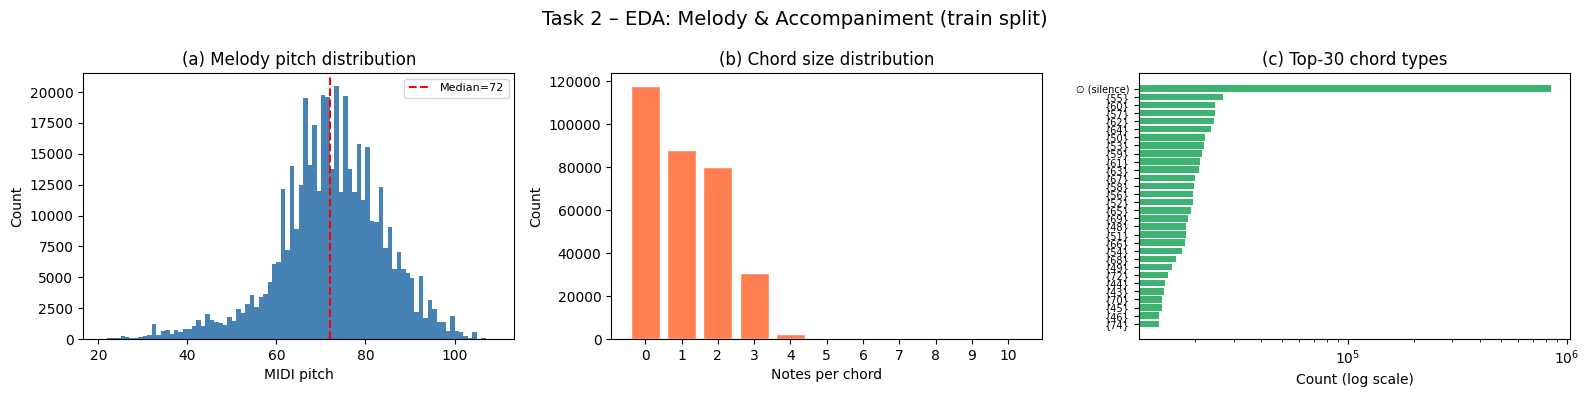

Melody rest fraction      : 12.2%
Avg notes per chord       : 1.10
Chord UNK rate (sample)   : 0.0%


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Task 2 – EDA: Melody & Accompaniment (train split)", fontsize=14)

# Sample first 2000 chunks for speed
_sample_mel = np.concatenate([c for c in t2_train_mel[:2000]])
_sample_chd = np.concatenate([c for c in t2_train_chd[:2000]])

# (a) Melody pitch distribution
ax = axes[0]
mel_pitches = _sample_mel[(_sample_mel != MEL_PAD) & (_sample_mel != MEL_REST)] + MEL_MIN
ax.hist(mel_pitches, bins=88, range=(MEL_MIN, MEL_MAX + 1),
        color="steelblue", edgecolor="none")
ax.set_xlabel("MIDI pitch"); ax.set_ylabel("Count")
ax.set_title("(a) Melody pitch distribution")
ax.axvline(np.median(mel_pitches), color="red", linestyle="--",
           label=f"Median={int(np.median(mel_pitches))}")
ax.legend(fontsize=8)

# (b) Chord size distribution (how many notes per chord)
ax = axes[1]
valid_chd = _sample_chd[(_sample_chd != CHORD_PAD) & (_sample_chd != CHORD_UNK)
                         & (_sample_chd != CHORD_BOS) & (_sample_chd != CHORD_EOS)]
chord_sizes = [len(id2chord[int(i)]) for i in valid_chd if int(i) in id2chord]
ax.hist(chord_sizes, bins=range(0, 12), color="coral",
        edgecolor="white", align="left", rwidth=0.8)
ax.set_xlabel("Notes per chord"); ax.set_ylabel("Count")
ax.set_title("(b) Chord size distribution")
ax.set_xticks(range(0, 11))

# (c) Top-30 chord type frequencies
ax = axes[2]
top30 = chord_counter.most_common(30)
bar_counts = [cnt for _, cnt in top30]

def chord_label(ch):
    if not ch:
        return "∅ (silence)"
    pitches = sorted(ch)
    label = ",".join(str(p) for p in pitches[:3])
    return "{" + label + ("…" if len(pitches) > 3 else "") + "}"

bar_labels = [chord_label(ch) for ch, _ in top30]
ax.barh(range(30), bar_counts[::-1], color="mediumseagreen")
ax.set_yticks(range(30))
ax.set_yticklabels(bar_labels[::-1], fontsize=7)
ax.set_xscale("log")
ax.set_xlabel("Count (log scale)")
ax.set_title("(c) Top-30 chord types")

plt.tight_layout()
plt.savefig("t2_eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()

rest_frac    = (_sample_mel[_sample_mel != MEL_PAD] == MEL_REST).mean()
avg_chd_size = np.mean(chord_sizes) if chord_sizes else 0.0
print(f"Melody rest fraction      : {rest_frac:.1%}")
print(f"Avg notes per chord       : {avg_chd_size:.2f}")
print(f"Chord UNK rate (sample)   : {(valid_chd == CHORD_UNK).mean() if len(valid_chd) else 0:.1%}")

## Task 2 — §2 Modelling

**Task formulation:** Given melody sequence $\mathbf{m} = (m_1, \ldots, m_T)$ (one pitch or REST per 16th-note timestep), generate the accompaniment $\mathbf{c} = (c_1, \ldots, c_T)$ (one chord token per timestep), maximizing $p(\mathbf{c} \mid \mathbf{m})$.

**Model:** An encoder-decoder transformer (`nn.Transformer`).
- **Encoder** reads the full melody sequence (non-causal, bidirectional self-attention).
- **Decoder** autoregressively generates chord tokens given encoder memory and previously generated chords (causal masked self-attention + cross-attention to encoder).
- Separate embedding layers for melody and chord tokens; shared sinusoidal positional encoding.
- Architecture: $d_\text{model}=256$, 8 heads, 4 encoder + 4 decoder layers, FFN dim 1024.

In [5]:
class HarmonizationDataset(Dataset):
    """
    Each item: (melody, dec_in, target) — all tensors of length T2_MAX_STEPS.

    Teacher forcing: decoder input is [BOS, c_0, c_1, ..., c_{T-2}];
    target is                         [c_0,  c_1, ..., c_{T-1}].
    """
    def __init__(self, mel_chunks, chd_chunks):
        self.mel = [torch.tensor(m, dtype=torch.long) for m in mel_chunks]
        self.chd = [torch.tensor(c, dtype=torch.long) for c in chd_chunks]

    def __len__(self):
        return len(self.mel)

    def __getitem__(self, idx):
        mel = self.mel[idx]                                         # (T,)
        chd = self.chd[idx]                                         # (T,)
        dec_in = torch.cat([torch.tensor([CHORD_BOS]), chd[:-1]])   # (T,)
        return mel, dec_in, chd                                     # target = chd


T2_BATCH = 32

t2_train_ds = HarmonizationDataset(t2_train_mel, t2_train_chd)
t2_val_ds   = HarmonizationDataset(t2_val_mel,   t2_val_chd)
t2_test_ds  = HarmonizationDataset(t2_test_mel,  t2_test_chd)

t2_train_loader = DataLoader(t2_train_ds, batch_size=T2_BATCH, shuffle=True,
                              num_workers=0, pin_memory=(DEVICE.type == "cuda"))
t2_val_loader   = DataLoader(t2_val_ds,   batch_size=T2_BATCH, shuffle=False,
                              num_workers=0, pin_memory=(DEVICE.type == "cuda"))
t2_test_loader  = DataLoader(t2_test_ds,  batch_size=T2_BATCH, shuffle=False,
                              num_workers=0, pin_memory=(DEVICE.type == "cuda"))

mel_b, dec_in_b, tgt_b = next(iter(t2_train_loader))
print(f"melody  batch : {mel_b.shape}    (encoder input)")
print(f"dec_in  batch : {dec_in_b.shape} (shifted chord — decoder input)")
print(f"target  batch : {tgt_b.shape}    (chord targets)")
print(f"Train batches : {len(t2_train_loader)}")
print(f"Val   batches : {len(t2_val_loader)}")

melody  batch : torch.Size([32, 256])    (encoder input)
dec_in  batch : torch.Size([32, 256]) (shifted chord — decoder input)
target  batch : torch.Size([32, 256])    (chord targets)
Train batches : 1075
Val   batches : 131


In [6]:
class MusicEncoderDecoder(nn.Module):
    """
    Encoder-decoder transformer for melody harmonization.

    Encoder: reads full melody sequence (bidirectional).
    Decoder: generates chord tokens autoregressively (causal self-attention
             + cross-attention to encoder memory).
    """

    def __init__(self, mel_vocab=MEL_VOCAB, chord_vocab=CHORD_VOCAB_SIZE,
                 d_model=256, nhead=8,
                 num_encoder_layers=4, num_decoder_layers=4,
                 dim_feedforward=1024, dropout=0.1,
                 max_len=T2_MAX_STEPS + 4):
        super().__init__()
        self.d_model = d_model

        self.mel_embed   = nn.Embedding(mel_vocab,   d_model, padding_idx=MEL_PAD)
        self.chord_embed = nn.Embedding(chord_vocab, d_model, padding_idx=CHORD_PAD)
        self.pos_enc     = SinusoidalPE(d_model, max_len, dropout)  # reuse Task 1 PE

        self.transformer = nn.Transformer(
            d_model=d_model, nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True,
            norm_first=True,
        )
        self.head = nn.Linear(d_model, chord_vocab)
        self._init_weights()

    def _init_weights(self):
        for emb in (self.mel_embed, self.chord_embed):
            nn.init.normal_(emb.weight, std=0.02)
        nn.init.zeros_(self.head.bias)
        nn.init.normal_(self.head.weight, std=0.02)

    def forward(self, src, tgt, src_pad_mask=None, tgt_pad_mask=None):
        """
        src          : (B, S) — melody token ids
        tgt          : (B, T) — decoder input chord ids (teacher-forced)
        src_pad_mask : (B, S) bool — True where melody is PAD
        tgt_pad_mask : (B, T) bool — True where decoder input is CHORD_PAD
        returns logits (B, T, chord_vocab)
        """
        T = tgt.size(1)
        causal_mask = nn.Transformer.generate_square_subsequent_mask(
            T, device=src.device)

        src_emb = self.pos_enc(self.mel_embed(src)   * math.sqrt(self.d_model))
        tgt_emb = self.pos_enc(self.chord_embed(tgt) * math.sqrt(self.d_model))

        out = self.transformer(
            src_emb, tgt_emb,
            tgt_mask=causal_mask,
            src_key_padding_mask=src_pad_mask,
            tgt_key_padding_mask=tgt_pad_mask,
            memory_key_padding_mask=src_pad_mask,
        )
        return self.head(out)


t2_model  = MusicEncoderDecoder().to(DEVICE)
t2_total  = sum(p.numel() for p in t2_model.parameters())
t2_train_ = sum(p.numel() for p in t2_model.parameters() if p.requires_grad)
print(f"Total parameters     : {t2_total:,}")
print(f"Trainable parameters : {t2_train_:,}")
print(t2_model)


def t2_compute_loss(model, src, dec_in, tgt):
    src_pad = (src    == MEL_PAD)
    tgt_pad = (dec_in == CHORD_PAD)
    logits  = model(src, dec_in, src_pad_mask=src_pad, tgt_pad_mask=tgt_pad)
    return F.cross_entropy(
        logits.reshape(-1, CHORD_VOCAB_SIZE),
        tgt.reshape(-1),
        ignore_index=CHORD_PAD,
    )


def t2_evaluate(model, loader, max_batches=None):
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for i, (mel, dec_in, tgt) in enumerate(loader):
            if max_batches and i >= max_batches:
                break
            mel, dec_in, tgt = mel.to(DEVICE), dec_in.to(DEVICE), tgt.to(DEVICE)
            loss = t2_compute_loss(model, mel, dec_in, tgt)
            total += loss.item(); n += 1
    model.train()
    return total / max(n, 1)

Total parameters     : 8,449,540
Trainable parameters : 8,449,540
MusicEncoderDecoder(
  (mel_embed): Embedding(90, 256, padding_idx=89)
  (chord_embed): Embedding(2052, 256, padding_idx=2049)
  (pos_enc): SinusoidalPE(
    (drop): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-3): 4 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
          )
          (linear1): Linear(in_features=256, out_features=1024, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=1024, out_features=256, bias=True)
          (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
          (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2

/home/aaron/anaconda3/lib/python3.11/site-packages/torch/nn/modules/transformer.py:143: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = TransformerEncoder(


## Task 2 — §3 Training

**Teacher forcing:** the decoder input is the ground-truth chord sequence shifted right by one position (prepend BOS, drop last token). The target is the original chord sequence. Loss is cross-entropy over chord tokens only; PAD tokens are excluded via `ignore_index`.

Optimizer: AdamW with the same warmup + cosine decay schedule used in Task 1 (`get_scheduler`). AMP fp16 is used when a CUDA GPU is available.

In [7]:
T2_LR           = 1e-4
T2_WEIGHT_DECAY = 1e-2
T2_NUM_EPOCHS   = 30
T2_PATIENCE     = 5
T2_WARMUP_STEPS = 1000

t2_optimizer    = torch.optim.AdamW(t2_model.parameters(),
                                    lr=T2_LR, weight_decay=T2_WEIGHT_DECAY)
t2_scaler       = torch.amp.GradScaler("cuda") if USE_AMP else None
t2_total_steps  = T2_NUM_EPOCHS * len(t2_train_loader)
t2_scheduler    = get_scheduler(t2_optimizer, T2_WARMUP_STEPS, t2_total_steps)

t2_best_val    = float("inf")
t2_patience_c  = 0
t2_history     = {"train_loss": [], "val_loss": [], "val_ppl": []}

print(f"Training Task 2 for up to {T2_NUM_EPOCHS} epochs")
print(f"Batches per epoch : {len(t2_train_loader)}")
print(f"Warmup steps      : {T2_WARMUP_STEPS}  /  Total: {t2_total_steps}\n")

t2_global_step = 0
for epoch in range(1, T2_NUM_EPOCHS + 1):
    t2_model.train()
    ep_loss, n_b = 0.0, 0

    for batch_idx, (mel, dec_in, tgt) in enumerate(t2_train_loader):
        mel, dec_in, tgt = mel.to(DEVICE), dec_in.to(DEVICE), tgt.to(DEVICE)
        t2_optimizer.zero_grad(set_to_none=True)

        if USE_AMP:
            with torch.amp.autocast("cuda", dtype=torch.float16):
                loss = t2_compute_loss(t2_model, mel, dec_in, tgt)
            t2_scaler.scale(loss).backward()
            t2_scaler.unscale_(t2_optimizer)
            torch.nn.utils.clip_grad_norm_(t2_model.parameters(), 1.0)
            t2_scaler.step(t2_optimizer)
            t2_scaler.update()
        else:
            loss = t2_compute_loss(t2_model, mel, dec_in, tgt)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(t2_model.parameters(), 1.0)
            t2_optimizer.step()

        t2_scheduler.step()
        ep_loss += loss.item(); n_b += 1; t2_global_step += 1

        if (batch_idx + 1) % 200 == 0:
            print(f"  Epoch {epoch:2d} | step {t2_global_step:6d} | "
                  f"loss={ep_loss/n_b:.4f} | lr={t2_scheduler.get_last_lr()[0]:.2e}")

    avg_train = ep_loss / n_b
    val_loss  = t2_evaluate(t2_model, t2_val_loader, max_batches=200)
    val_ppl   = math.exp(val_loss)

    t2_history["train_loss"].append(avg_train)
    t2_history["val_loss"].append(val_loss)
    t2_history["val_ppl"].append(val_ppl)

    print(f"Epoch {epoch:2d} | train={avg_train:.4f} | val={val_loss:.4f} | ppl={val_ppl:.1f}")

    if val_loss < t2_best_val:
        t2_best_val   = val_loss
        t2_patience_c = 0
        torch.save({
            "epoch": epoch,
            "model_state": t2_model.state_dict(),
            "val_loss": val_loss, "val_ppl": val_ppl,
            "history": t2_history,
            "chord2id": chord2id, "id2chord": id2chord,
        }, CKPT_DIR / "best_model_task2.pt")
        print(f"  -> Saved best checkpoint (val_ppl={val_ppl:.1f})")
    else:
        t2_patience_c += 1
        if t2_patience_c >= T2_PATIENCE:
            print(f"Early stopping after epoch {epoch}.")
            break

print(f"\nBest validation perplexity: {math.exp(t2_best_val):.2f}")

Training Task 2 for up to 30 epochs
Batches per epoch : 1075
Warmup steps      : 1000  /  Total: 32250



/home/aaron/anaconda3/lib/python3.11/site-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


  Epoch  1 | step    200 | loss=6.1526 | lr=2.00e-05
  Epoch  1 | step    400 | loss=5.3316 | lr=4.00e-05
  Epoch  1 | step    600 | loss=4.8578 | lr=6.00e-05
  Epoch  1 | step    800 | loss=4.5731 | lr=8.00e-05
  Epoch  1 | step   1000 | loss=4.3530 | lr=1.00e-04
Epoch  1 | train=4.2794 | val=3.1567 | ppl=23.5
  -> Saved best checkpoint (val_ppl=23.5)
  Epoch  2 | step   1275 | loss=3.1510 | lr=1.00e-04
  Epoch  2 | step   1475 | loss=3.0645 | lr=9.99e-05
  Epoch  2 | step   1675 | loss=2.9842 | lr=9.99e-05
  Epoch  2 | step   1875 | loss=2.9075 | lr=9.98e-05
  Epoch  2 | step   2075 | loss=2.8433 | lr=9.97e-05
Epoch  2 | train=2.8227 | val=2.4512 | ppl=11.6
  -> Saved best checkpoint (val_ppl=11.6)
  Epoch  3 | step   2350 | loss=2.4757 | lr=9.95e-05
  Epoch  3 | step   2550 | loss=2.4444 | lr=9.94e-05
  Epoch  3 | step   2750 | loss=2.4231 | lr=9.92e-05
  Epoch  3 | step   2950 | loss=2.4023 | lr=9.90e-05
  Epoch  3 | step   3150 | loss=2.3795 | lr=9.88e-05
Epoch  3 | train=2.3710 |

## Task 2 — §4 Evaluation

### Baselines

Three baselines are compared against the encoder-decoder model:

| Baseline | Description |
|---|---|
| **Most-common-chord** | Always predict the single most frequent chord in training data — a melody-agnostic lower bound |
| **Markov trigram** | $P(c_t \mid m_t, c_{t-1})$ estimated from training co-occurrence counts; uses add-one smoothing and melody-conditioned context |
| **Task 1 prefix (REMI LM)** | The already-trained Task 1 causal transformer (unconditioned); prepend REMI-encoded melody tokens as a prefix and sample the continuation — no retraining |

### Metrics

- **Perplexity** (lower = better): cross-entropy on ground-truth chord sequences; not applicable for most-common-chord.
- **Pitch class histogram overlap** (higher = better): $\sum_{pc=0}^{11} \min(\hat{h}_{pc}, h_{pc})$ where histograms are normalized to sum to 1.
- **Harmonic consistency** (higher = better): fraction of timesteps where at least one accompaniment note forms a consonant interval {0, 3, 4, 7, 8, 9, 12} semitones with the melody note.
- **Note density**: average number of accompaniment notes per timestep (vs. ground truth).

In [7]:
# ── Most-common-chord baseline ────────────────────────────────────────────────
_all_train_chd = np.concatenate(t2_train_chd)
_valid_train   = _all_train_chd[(_all_train_chd != CHORD_PAD)
                                 & (_all_train_chd != CHORD_UNK)
                                 & (_all_train_chd != CHORD_BOS)
                                 & (_all_train_chd != CHORD_EOS)]
chd_train_counter  = collections.Counter(_valid_train.tolist())
most_common_chord_id = chd_train_counter.most_common(1)[0][0]

print(f"Most common chord id : {most_common_chord_id}")
print(f"  pitches : {sorted(id2chord.get(most_common_chord_id, set()))}")
print(f"  occurs  : {chd_train_counter[most_common_chord_id]:,} times in training data")


# ── Markov trigram baseline: P(c_t | m_t, c_{t-1}) ───────────────────────────
class MarkovHarmonizer:
    """
    Trigram model: P(chord_t | melody_t, chord_{t-1}).
    Counts are collected from training (mel, chord) pairs.
    Perplexity uses add-one (Laplace) smoothing.
    """

    def __init__(self, chord_vocab_size=CHORD_VOCAB_SIZE):
        self.V      = chord_vocab_size
        # counts[(mel_tok, prev_chord)] → {next_chord: count}
        self.counts = collections.defaultdict(
            lambda: collections.defaultdict(int))

    def train(self, mel_chunks, chd_chunks):
        for mel, chd in tqdm(zip(mel_chunks, chd_chunks),
                              total=len(mel_chunks), desc="Markov train"):
            prev_c = CHORD_BOS
            for m, c in zip(mel, chd):
                m, c = int(m), int(c)
                if c in (CHORD_PAD, CHORD_BOS, CHORD_EOS):
                    prev_c = CHORD_BOS; continue
                self.counts[(m, prev_c)][c] += 1
                prev_c = c

    def sample(self, mel_tok, prev_chord, temperature=1.0):
        key  = (int(mel_tok), int(prev_chord))
        dist = self.counts.get(key, None)
        if not dist:
            # fall back to melody-token-only key
            dist = self.counts.get((int(mel_tok), CHORD_BOS), None)
        if not dist:
            return most_common_chord_id
        ids  = list(dist.keys())
        cnts = np.array(list(dist.values()), dtype=float)
        cnts = cnts ** (1.0 / max(temperature, 1e-6))
        cnts /= cnts.sum()
        return int(np.random.choice(ids, p=cnts))

    def perplexity(self, mel_chunks, chd_chunks, max_chunks=3000):
        total_ll, total_n = 0.0, 0
        for mel, chd in zip(mel_chunks[:max_chunks], chd_chunks[:max_chunks]):
            prev_c = CHORD_BOS
            for m, c in zip(mel, chd):
                m, c = int(m), int(c)
                if c in (CHORD_PAD, CHORD_UNK, CHORD_BOS, CHORD_EOS):
                    prev_c = CHORD_BOS; continue
                key   = (m, prev_c)
                dist  = self.counts.get(key, {})
                denom = sum(dist.values()) + self.V
                numer = dist.get(c, 0) + 1
                total_ll += math.log(numer / denom)
                total_n  += 1
                prev_c = c
        return math.exp(-total_ll / max(total_n, 1))


markov = MarkovHarmonizer()
markov.train(t2_train_mel, t2_train_chd)

markov_val_ppl  = markov.perplexity(t2_val_mel,  t2_val_chd,  max_chunks=2000)
markov_test_ppl = markov.perplexity(t2_test_mel, t2_test_chd, max_chunks=2000)
print(f"\nMarkov val  perplexity : {markov_val_ppl:.2f}")
print(f"Markov test perplexity : {markov_test_ppl:.2f}")

Most common chord id : 0
  pitches : []
  occurs  : 1,605,599 times in training data


Markov train:   0%|          | 0/34400 [00:00<?, ?it/s]


Markov val  perplexity : 88.04
Markov test perplexity : 79.71


In [8]:
# ── Task 1 prefix baseline ────────────────────────────────────────────────────
# All Task 1 definitions required for this baseline are re-declared locally so
# this cell runs independently of the Task 1 section.

from miditok import REMI as _T1_REMI_CLS

_t1_tok      = _T1_REMI_CLS()
_T1_VOCAB    = len(_t1_tok.vocab)
_T1_PAD_ID   = _t1_tok["PAD_None"]
_T1_BOS_ID   = _t1_tok["BOS_None"]
_T1_EOS_ID   = _t1_tok["EOS_None"]
_T1_SEQ_LEN  = 512
_T1_STRIDE   = 256
_T1_D_MODEL  = 256; _T1_NHEAD = 8; _T1_LAYERS = 4
_T1_FFN      = 1024; _T1_DROP  = 0.1


def _t1_midi_to_ids(path):
    result = _t1_tok.encode(path)
    seq = result[0] if isinstance(result, list) else result
    return list(seq.ids)


class _T1MusicLM(nn.Module):
    """Task 1 causal LM — identical architecture to Task 1 MusicLM."""
    def __init__(self):
        super().__init__()
        self.d_model = _T1_D_MODEL
        self.embed   = nn.Embedding(_T1_VOCAB, _T1_D_MODEL, padding_idx=_T1_PAD_ID)
        self.pos_enc = SinusoidalPE(_T1_D_MODEL, 1024, _T1_DROP)
        enc_layer    = nn.TransformerEncoderLayer(
            d_model=_T1_D_MODEL, nhead=_T1_NHEAD,
            dim_feedforward=_T1_FFN, dropout=_T1_DROP,
            batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(
            enc_layer, num_layers=_T1_LAYERS, enable_nested_tensor=False)
        self.head = nn.Linear(_T1_D_MODEL, _T1_VOCAB)

    @staticmethod
    def make_causal_mask(seq_len, device):
        mask = torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1)
        return mask.masked_fill(mask.bool(), float("-inf"))

    def forward(self, x, pad_mask=None):
        T      = x.size(1)
        causal = self.make_causal_mask(T, x.device)
        emb    = self.pos_enc(self.embed(x) * math.sqrt(self.d_model))
        out    = self.transformer(emb, mask=causal,
                                  src_key_padding_mask=pad_mask, is_causal=True)
        return self.head(out)


@torch.no_grad()
def _t1_generate(model, primer_ids, max_new_tokens=512,
                 temperature=0.9, top_k=50, device=DEVICE):
    model.eval()
    generated = list(primer_ids)
    for _ in range(max_new_tokens):
        ctx    = generated[-_T1_SEQ_LEN:]
        x      = torch.tensor([ctx], dtype=torch.long, device=device)
        pad    = (x == _T1_PAD_ID)
        logits = model(x, pad)[0, -1, :]
        logits = logits / max(temperature, 1e-6)
        if top_k > 0:
            topk_vals, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < topk_vals[-1]] = float("-inf")
        probs    = torch.softmax(logits, dim=-1)
        next_tok = torch.multinomial(probs, 1).item()
        generated.append(next_tok)
        if next_tok == _T1_EOS_ID:
            break
    return generated


def _t1_evaluate(model, test_rows, max_files=20):
    """Approximate perplexity on a small sample of test MIDI files."""
    model.eval()
    total_loss, n = 0.0, 0
    with torch.no_grad():
        for _, row in test_rows.head(max_files).iterrows():
            path = DATA_DIR / row["midi_filename"]
            try:
                ids = _t1_midi_to_ids(path)
            except Exception:
                continue
            for start in range(0, max(1, len(ids) - _T1_SEQ_LEN + 1), _T1_STRIDE):
                chunk = ids[start : start + _T1_SEQ_LEN]
                if len(chunk) < _T1_SEQ_LEN:
                    chunk += [_T1_PAD_ID] * (_T1_SEQ_LEN - len(chunk))
                x = torch.tensor([chunk[:-1]], dtype=torch.long, device=DEVICE)
                y = torch.tensor([chunk[1:]],  dtype=torch.long, device=DEVICE)
                pad = (x == _T1_PAD_ID)
                logits = model(x, pad)
                loss = F.cross_entropy(logits.reshape(-1, _T1_VOCAB),
                                       y.reshape(-1), ignore_index=_T1_PAD_ID)
                total_loss += loss.item(); n += 1
    model.train()
    return total_loss / max(n, 1)


T1_PREFIX_CKPT = CKPT_DIR / "best_model.pt"

if T1_PREFIX_CKPT.exists():
    _t1_ckpt        = torch.load(T1_PREFIX_CKPT, map_location=DEVICE,
                                  weights_only=False)
    t1_prefix_model = _T1MusicLM().to(DEVICE)
    t1_prefix_model.load_state_dict(_t1_ckpt["model_state"])
    t1_prefix_model.eval()
    print(f"Loaded Task 1 prefix model  (epoch={_t1_ckpt['epoch']}, "
          f"val_ppl={_t1_ckpt['val_ppl']:.2f})")

    _test_rows         = df[df["split"] == "test"]
    t1_prefix_test_ppl = math.exp(_t1_evaluate(t1_prefix_model, _test_rows))
    print(f"Task 1 prefix test perplexity (REMI, ~{min(20, len(_test_rows))} files): "
          f"{t1_prefix_test_ppl:.2f}")

    def task1_prefix_generate(mel_midi_path, max_new=256, temperature=0.9, top_k=50):
        """REMI-encode a MIDI file, prepend as prefix, sample continuation."""
        primer = _t1_midi_to_ids(mel_midi_path)[:64]
        return _t1_generate(t1_prefix_model, primer,
                             max_new_tokens=max_new,
                             temperature=temperature, top_k=top_k)

else:
    t1_prefix_test_ppl = float("nan")
    t1_prefix_model    = None
    print("Task 1 checkpoint not found — prefix baseline perplexity set to NaN.")
    print("Train Task 1 first (or copy best_model.pt to checkpoints/) to enable it.")

Loaded Task 1 prefix model  (epoch=30, val_ppl=7.59)


/home/aaron/anaconda3/lib/python3.11/site-packages/torch/nn/modules/transformer.py:429: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


Task 1 prefix test perplexity (REMI, ~20 files): 7.54


Task 1 prefix test perplexity (REMI, ~20 files): 7.54


In [9]:
# ── Load best Task 2 checkpoint ───────────────────────────────────────────────
t2_ckpt = torch.load(CKPT_DIR / "best_model_task2.pt", map_location=DEVICE,
                                 weights_only=False)  # trusted local checkpoint
t2_model.load_state_dict(t2_ckpt["model_state"])
t2_history = t2_ckpt["history"]
print(f"Loaded Task 2 best checkpoint  "
      f"(epoch={t2_ckpt['epoch']}, val_ppl={t2_ckpt['val_ppl']:.2f})")


# ── Metric helpers ────────────────────────────────────────────────────────────
CONSONANT_INTERVALS = {0, 3, 4, 7, 8, 9, 12}


def chord_ids_to_pitches(chord_id_arr, id2chord):
    """Flatten a sequence of chord token ids to a list of MIDI pitches."""
    pitches = []
    for cid in chord_id_arr:
        cid = int(cid)
        if cid in id2chord:
            pitches.extend(id2chord[cid])
    return pitches


def pitch_class_histogram(pitches):
    hist = np.zeros(12)
    for p in pitches:
        hist[p % 12] += 1
    s = hist.sum()
    return hist / s if s > 0 else hist


def histogram_overlap(h1, h2):
    """Intersection-based overlap; both histograms should be normalized."""
    return float(np.sum(np.minimum(h1, h2)))


def harmonic_consistency(melody_ids, chord_id_seq, id2chord):
    """
    Fraction of non-silent timesteps where at least one chord note is
    consonant with the melody note (interval in CONSONANT_INTERVALS).
    """
    consonant, total = 0, 0
    for m, c in zip(melody_ids, chord_id_seq):
        m, c = int(m), int(c)
        if m in (MEL_REST, MEL_PAD):
            continue
        if c not in id2chord or c in (CHORD_PAD, CHORD_UNK, CHORD_BOS, CHORD_EOS):
            continue
        chord_pitches = id2chord[c]
        if not chord_pitches:
            continue
        total += 1
        mel_pc = (m + MEL_MIN) % 12   # m is compact pitch id, not raw MIDI
        for cp in chord_pitches:
            interval = abs(cp % 12 - mel_pc) % 12
            if interval in CONSONANT_INTERVALS:
                consonant += 1
                break
    return consonant / max(total, 1)


def note_density(chord_id_arr, id2chord):
    """Average number of pitches per valid (non-special) chord token."""
    sizes = [
        len(id2chord[int(c)])
        for c in chord_id_arr
        if int(c) in id2chord
        and int(c) not in (CHORD_PAD, CHORD_UNK, CHORD_BOS, CHORD_EOS)
    ]
    return float(np.mean(sizes)) if sizes else 0.0


@torch.no_grad()
def t2_model_perplexity(model, loader, max_batches=400):
    model.eval()
    total, n = 0.0, 0
    for i, (mel, dec_in, tgt) in enumerate(loader):
        if i >= max_batches:
            break
        mel, dec_in, tgt = mel.to(DEVICE), dec_in.to(DEVICE), tgt.to(DEVICE)
        loss = t2_compute_loss(model, mel, dec_in, tgt)
        total += loss.item(); n += 1
    model.train()
    return math.exp(total / max(n, 1))


@torch.no_grad()
def run_greedy_generation(model, mel_chunks, chd_chunks, n_samples=400):
    """
    Teacher-forced greedy decode: given ground-truth decoder input, return
    argmax predictions. Used for pitch/harmonic/density metrics only.
    """
    model.eval()
    all_gen, all_ref, all_mel = [], [], []
    ds     = HarmonizationDataset(mel_chunks[:n_samples], chd_chunks[:n_samples])
    loader = DataLoader(ds, batch_size=32, shuffle=False)
    for mel_b, dec_in_b, tgt_b in loader:
        mel_b    = mel_b.to(DEVICE)
        dec_in_b = dec_in_b.to(DEVICE)
        logits   = model(mel_b, dec_in_b,
                         src_pad_mask=(mel_b    == MEL_PAD),
                         tgt_pad_mask=(dec_in_b == CHORD_PAD))
        gen = logits.argmax(-1).cpu().numpy()
        all_gen.append(gen)
        all_ref.append(tgt_b.numpy())
        all_mel.append(mel_b.cpu().numpy())
    model.train()
    return (np.concatenate(all_gen),
            np.concatenate(all_ref),
            np.concatenate(all_mel))

Loaded Task 2 best checkpoint  (epoch=25, val_ppl=6.85)


/home/aaron/anaconda3/lib/python3.11/site-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(
/home/aaron/anaconda3/lib/python3.11/site-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


,Model,PPL ↓,PC Hist Overlap ↑,Harm. Consist. ↑,Note Density
0,Reference (ground truth),–,1.000,0.710,1.10
1,Most-common-chord,–,0.000,0.000,0.00
2,Markov trigram,79.7,0.897,0.771,1.25
3,Task 1 prefix (REMI LM),7.5,–,–,–
4,Enc-Dec Transformer (ours),6.8,0.972,0.696,0.82


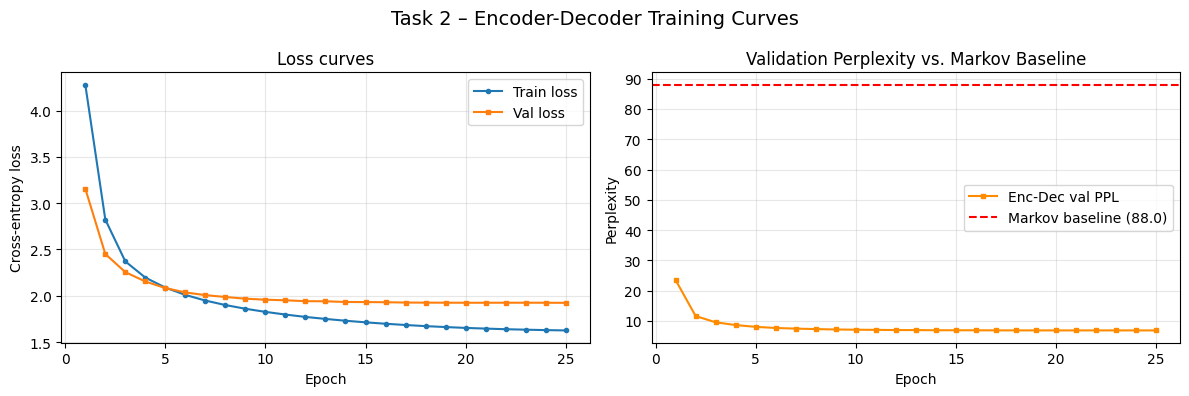

In [10]:
N_EVAL = 300   # number of test chunks used for metric estimation

# ── Reference (ground truth) ──────────────────────────────────────────────────
ref_mel_flat = np.concatenate([np.array(c) for c in t2_test_mel[:N_EVAL]])
ref_chd_flat = np.concatenate([np.array(c) for c in t2_test_chd[:N_EVAL]])
ref_pitches  = chord_ids_to_pitches(ref_chd_flat, id2chord)
ref_hist     = pitch_class_histogram(ref_pitches)
ref_density  = note_density(ref_chd_flat, id2chord)
ref_harm     = float(np.mean([
    harmonic_consistency(np.array(t2_test_mel[i]), np.array(t2_test_chd[i]), id2chord)
    for i in range(N_EVAL)
]))

# ── Enc-Dec model ──────────────────────────────────────────────────────────────
enc_dec_ppl          = t2_model_perplexity(t2_model, t2_test_loader, max_batches=300)
gen_chd, _, gen_mel  = run_greedy_generation(t2_model, t2_test_mel, t2_test_chd,
                                              n_samples=N_EVAL)
enc_dec_hist = pitch_class_histogram(chord_ids_to_pitches(gen_chd.flatten(), id2chord))
enc_dec_harm = float(np.mean([
    harmonic_consistency(gen_mel[i], gen_chd[i], id2chord)
    for i in range(len(gen_mel))
]))
enc_dec_nd   = note_density(gen_chd.flatten(), id2chord)

# ── Most-common-chord baseline ─────────────────────────────────────────────────
mcc_pred  = np.full(N_EVAL * T2_MAX_STEPS, most_common_chord_id, dtype=np.int32)
mcc_hist  = pitch_class_histogram(chord_ids_to_pitches(mcc_pred, id2chord))
mcc_harm  = float(np.mean([
    harmonic_consistency(
        np.array(t2_test_mel[i]),
        np.full(T2_MAX_STEPS, most_common_chord_id, dtype=np.int32),
        id2chord)
    for i in range(min(N_EVAL, len(t2_test_mel)))
]))
mcc_nd    = note_density(mcc_pred[:T2_MAX_STEPS], id2chord)

# ── Markov trigram baseline ────────────────────────────────────────────────────
markov_gen = []
for mel_c in t2_test_mel[:N_EVAL]:
    pred, prev_c = [], CHORD_BOS
    for m in mel_c:
        c = markov.sample(m, prev_c)
        pred.append(c); prev_c = c
    markov_gen.append(np.array(pred, dtype=np.int32))

markov_gen_flat = np.concatenate(markov_gen)
markov_hist = pitch_class_histogram(chord_ids_to_pitches(markov_gen_flat, id2chord))
markov_harm = float(np.mean([
    harmonic_consistency(np.array(t2_test_mel[i]), markov_gen[i], id2chord)
    for i in range(N_EVAL)
]))
markov_nd   = note_density(markov_gen_flat, id2chord)

# ── Results table ──────────────────────────────────────────────────────────────
results = pd.DataFrame({
    "Model": [
        "Reference (ground truth)",
        "Most-common-chord",
        "Markov trigram",
        "Task 1 prefix (REMI LM)",
        "Enc-Dec Transformer (ours)",
    ],
    "PPL ↓": [
        "–",
        "–",
        f"{markov_test_ppl:.1f}",
        f"{t1_prefix_test_ppl:.1f}" if not math.isnan(t1_prefix_test_ppl) else "N/A",
        f"{enc_dec_ppl:.1f}",
    ],
    "PC Hist Overlap ↑": [
        "1.000",
        f"{histogram_overlap(ref_hist, mcc_hist):.3f}",
        f"{histogram_overlap(ref_hist, markov_hist):.3f}",
        "–",
        f"{histogram_overlap(ref_hist, enc_dec_hist):.3f}",
    ],
    "Harm. Consist. ↑": [
        f"{ref_harm:.3f}",
        f"{mcc_harm:.3f}",
        f"{markov_harm:.3f}",
        "–",
        f"{enc_dec_harm:.3f}",
    ],
    "Note Density": [
        f"{ref_density:.2f}",
        f"{mcc_nd:.2f}",
        f"{markov_nd:.2f}",
        "–",
        f"{enc_dec_nd:.2f}",
    ],
})
display(results)

# Training curves
if t2_history.get("train_loss"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("Task 2 – Encoder-Decoder Training Curves", fontsize=14)
    ep = range(1, len(t2_history["train_loss"]) + 1)

    axes[0].plot(ep, t2_history["train_loss"], label="Train loss",
                 marker="o", markersize=3)
    axes[0].plot(ep, t2_history["val_loss"],   label="Val loss",
                 marker="s", markersize=3)
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-entropy loss")
    axes[0].set_title("Loss curves"); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(ep, t2_history["val_ppl"], color="darkorange",
                 marker="s", markersize=3, label="Enc-Dec val PPL")
    axes[1].axhline(markov_val_ppl, color="red", linestyle="--",
                    label=f"Markov baseline ({markov_val_ppl:.1f})")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Perplexity")
    axes[1].set_title("Validation Perplexity vs. Markov Baseline")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("t2_training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

## Task 2 — §5 Inference & Generation

Autoregressive decoding: the encoder reads the full melody sequence once, producing a fixed memory tensor. The decoder then generates chord tokens one at a time, using the encoder memory (via cross-attention) and its own previous outputs (via causal self-attention). Temperature controls the sharpness of the sampling distribution.

In [11]:
@torch.no_grad()
def harmonize(model, melody_ids, temperature=1.0, max_len=T2_MAX_STEPS,
              device=DEVICE):
    """
    Autoregressively generate an accompaniment for a given melody sequence.

    Parameters
    ----------
    model       : trained MusicEncoderDecoder
    melody_ids  : array-like of int, shape (T,) — compact ids 0..(MEL_MAX-MEL_MIN)
                  for notes, MEL_REST (silent), optionally MEL_PAD (padded)
    temperature : float — higher = more random, 0.8 / 1.0 / 1.2 recommended
    max_len     : int   — maximum number of chord tokens to generate

    Returns
    -------
    list of chord token ids (length ≤ max_len)
    """
    model.eval()
    T = min(len(melody_ids), max_len)

    mel_np = np.array(melody_ids[:T], dtype=np.int32)
    if len(mel_np) < max_len:
        mel_np = np.concatenate([mel_np,
                                  np.full(max_len - len(mel_np), MEL_PAD,
                                          dtype=np.int32)])

    src          = torch.tensor([mel_np], dtype=torch.long, device=device)
    src_pad_mask = (src == MEL_PAD)

    # Encode melody once
    src_emb = model.pos_enc(model.mel_embed(src) * math.sqrt(model.d_model))
    memory  = model.transformer.encoder(src_emb,
                                         src_key_padding_mask=src_pad_mask)

    generated = [CHORD_BOS]
    for _ in range(T):
        dec_in  = torch.tensor([generated], dtype=torch.long, device=device)
        tgt_emb = model.pos_enc(
            model.chord_embed(dec_in) * math.sqrt(model.d_model))
        t_len   = dec_in.size(1)
        causal  = nn.Transformer.generate_square_subsequent_mask(
            t_len, device=device)
        out     = model.transformer.decoder(
            tgt_emb, memory,
            tgt_mask=causal,
            memory_key_padding_mask=src_pad_mask)

        logits   = model.head(out[0, -1, :]) / max(temperature, 1e-6)
        probs    = torch.softmax(logits, dim=-1)
        next_c   = torch.multinomial(probs, 1).item()
        generated.append(next_c)
        if next_c == CHORD_EOS:
            break

    return generated[1:]   # strip leading BOS


def reconstruct_midi(melody_ids, chord_ids, id2chord,
                     ticks_per_beat=480,
                     steps_per_beat=T2_STEPS_PER_BEAT,
                     output_path=None):
    """
    Build a two-track MIDI file from aligned melody + chord token sequences.

    Track 0 : melody (single notes)
    Track 1 : accompaniment (chords)
    """
    ticks_per_step = ticks_per_beat // steps_per_beat
    score     = symusic.Score(ticks_per_beat)   # positional: tpq
    mel_track = symusic.Track()
    acc_track = symusic.Track()

    for t, (m, c) in enumerate(zip(melody_ids, chord_ids)):
        m, c = int(m), int(c)
        tick = t * ticks_per_step
        dur  = ticks_per_step

        if m not in (MEL_REST, MEL_PAD):
            mel_track.notes.append(
                symusic.Note(time=tick, duration=dur, pitch=m + MEL_MIN, velocity=80))

        if c in id2chord and c not in (CHORD_PAD, CHORD_UNK,
                                        CHORD_BOS, CHORD_EOS):
            for p in id2chord[c]:
                acc_track.notes.append(
                    symusic.Note(time=tick, duration=dur, pitch=p, velocity=60))

    score.tracks.append(mel_track)
    score.tracks.append(acc_track)

    if output_path is not None:
        score.dump_midi(str(output_path))
    return score

In [12]:
import shutil

# Presentation exports: one folder per test chunk (same indices as before: t2_test_mel[i])
OUT = Path("generated_task2")
OUT.mkdir(exist_ok=True)


def _ticks_per_step(ticks_per_beat=480, steps_per_beat=T2_STEPS_PER_BEAT):
    return ticks_per_beat // steps_per_beat


def write_melody_only_midi(melody_ids, output_path,
                           ticks_per_beat=480, steps_per_beat=T2_STEPS_PER_BEAT):
    """Single-track MIDI: skyline melody only (PAD/REST → silence)."""
    tps = _ticks_per_step(ticks_per_beat, steps_per_beat)
    score = symusic.Score(ticks_per_beat)
    tr = symusic.Track()
    for t, m in enumerate(melody_ids):
        m = int(m)
        tick = t * tps
        dur = tps
        if m not in (MEL_REST, MEL_PAD):
            tr.notes.append(
                symusic.Note(time=tick, duration=dur, pitch=m + MEL_MIN, velocity=88))
    score.tracks.append(tr)
    score.dump_midi(str(output_path))


def write_accompaniment_only_midi(chord_ids, id2chord, output_path,
                                 ticks_per_beat=480, steps_per_beat=T2_STEPS_PER_BEAT):
    """Single-track MIDI: accompaniment chord voicings only."""
    tps = _ticks_per_step(ticks_per_beat, steps_per_beat)
    score = symusic.Score(ticks_per_beat)
    tr = symusic.Track()
    for t, c in enumerate(chord_ids):
        c = int(c)
        tick = t * tps
        dur = tps
        if c in id2chord and c not in (CHORD_PAD, CHORD_UNK, CHORD_BOS, CHORD_EOS):
            for p in id2chord[c]:
                tr.notes.append(
                    symusic.Note(time=tick, duration=dur, pitch=p, velocity=72))
    score.tracks.append(tr)
    score.dump_midi(str(output_path))


def markov_accompaniment_for_melody(mel_chunk):
    """Same Markov trigram baseline as evaluation: P(c_t | m_t, c_{t-1})."""
    pred, prev_c = [], CHORD_BOS
    for m in mel_chunk:
        c = markov.sample(int(m), prev_c)
        pred.append(c)
        prev_c = c
    return np.array(pred, dtype=np.int32)


# Generate 5 harmonized examples using different temperatures
TEMPERATURES = [0.8, 1.0, 1.0, 1.2, 1.0]
t2_gen_files = []

for i in range(5):
    mel_c   = t2_test_mel[i]
    ref_chd = t2_test_chd[i]
    temp    = TEMPERATURES[i]
    tag     = f"sample_{i + 1}"

    # Original melody & original (ground-truth) accompaniment — separate stems
    write_melody_only_midi(mel_c, OUT / f"{tag}_melody_original.mid")
    write_accompaniment_only_midi(ref_chd, id2chord, OUT / f"{tag}_accompaniment_original.mid")

    # Markov baseline accompaniment for this same melody chunk
    markov_chd = markov_accompaniment_for_melody(mel_c)
    write_accompaniment_only_midi(markov_chd, id2chord,
                                  OUT / f"{tag}_accompaniment_markov_baseline.mid")

    # Full ground-truth duet (same chunk) — handy for A/B in slides
    reconstruct_midi(mel_c, ref_chd, id2chord,
                     output_path=OUT / f"{tag}_ground_truth_melody_plus_accompaniment.mid")

    try:
        gen_chord_ids = harmonize(t2_model, mel_c, temperature=temp)
        L = min(len(mel_c), len(gen_chord_ids))

        out_path = OUT / f"{tag}_harmonization_transformer_temp{temp}.mid"
        reconstruct_midi(mel_c[:L], gen_chord_ids[:L], id2chord, output_path=out_path)
        t2_gen_files.append(out_path)

        n_mel = sum(1 for m in mel_c[:L] if m not in (MEL_REST, MEL_PAD))
        n_chd = sum(len(id2chord.get(int(c), set())) for c in gen_chord_ids[:L]
                    if int(c) in id2chord
                    and int(c) not in (CHORD_PAD, CHORD_UNK, CHORD_BOS, CHORD_EOS))
        print(f"Sample {i + 1} (temp={temp}): exported to {OUT.name}/ ({L} steps, "
              f"{n_mel} melody notes, {n_chd} chord notes in transformer output)")
    except Exception as e:
        print(f"  Sample {i + 1}: transformer error — {e}")

if t2_gen_files:
    shutil.copy(t2_gen_files[0], "symbolic_conditioned.mid")
    print(f"\nsymbolic_conditioned.mid  ←  {t2_gen_files[0]}")

print(f"\nAll presentation MIDIs written under: {OUT.resolve()}")

print("\nSubmission file checklist:")
for f in ["symbolic_unconditioned.mid", "symbolic_conditioned.mid",
          "t2_eda_plots.png", "t2_training_curves.png"]:
    exists = Path(f).exists()
    size   = Path(f).stat().st_size / 1024 if exists else 0.0
    status = "OK" if exists else "MISSING"
    print(f"  [{status}]  {f:<40}  {size:8.1f} KB")

/tmp/ipykernel_108656/656937037.py:28: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  src          = torch.tensor([mel_np], dtype=torch.long, device=device)


Sample 1 (temp=0.8): exported to generated_task2/ (256 steps, 225 melody notes, 181 chord notes in transformer output)
Sample 2 (temp=1.0): exported to generated_task2/ (256 steps, 212 melody notes, 289 chord notes in transformer output)
Sample 3 (temp=1.0): exported to generated_task2/ (256 steps, 209 melody notes, 155 chord notes in transformer output)
Sample 4 (temp=1.2): exported to generated_task2/ (256 steps, 229 melody notes, 203 chord notes in transformer output)
Sample 5 (temp=1.0): exported to generated_task2/ (256 steps, 223 melody notes, 252 chord notes in transformer output)

symbolic_conditioned.mid  ←  generated_task2/sample_1_harmonization_transformer_temp0.8.mid

All presentation MIDIs written under: /mnt/c/Users/Aaron/Desktop/CSE-153-Assignment-2/generated_task2

Submission file checklist:
  [OK]  symbolic_unconditioned.mid                     1.1 KB
  [OK]  symbolic_conditioned.mid                       3.1 KB
  [OK]  t2_eda_plots.png                             108.

## Task 2 — Discussion of Related Work

### Melody Harmonization and Conditioned Generation

Melody harmonization is a conditioned symbolic generation task. Instead of generating music from scratch, the model generates accompaniment given an input melody. In our formulation, the model learns $p(\text{chords} \mid \text{melody})$: the encoder reads the extracted melody sequence, and the decoder predicts the aligned accompaniment chord sequence.

This makes Task 2 different from Task 1. Task 1 learns an unconditional distribution over music tokens, while Task 2 must generate output that is musically compatible with a specific input melody.

**Reference:**  
Hadjeres, G., Pachet, F., & Nielsen, F. (2017). *DeepBach: A Steerable Model for Bach Chorales Generation.* ICML 2017.

---

### Neural Harmonization Systems

Prior neural harmonization systems often focus on Bach chorales, where the goal is to generate missing voices or harmonize a melody. **DeepBach** showed that neural networks can produce convincing Bach-style harmonizations by modeling musical context around each note. **Coconet** later framed harmonization as an infilling problem, completing missing musical material from surrounding notes.

Our Task 2 follows the same general idea of generating harmonic material from existing musical input. However, our setting is less constrained than Bach chorales: MAESTRO contains expressive solo piano performances with denser textures, variable timing, and performance-level articulation. We therefore extract melody/accompaniment pairs using the skyline algorithm and train a model to predict chord sequences from melody sequences.

**References:**  
Hadjeres, G., Pachet, F., & Nielsen, F. (2017). *DeepBach: A Steerable Model for Bach Chorales Generation.* ICML 2017.  
Huang, C. Z. A., Cooijmans, T., Roberts, A., Courville, A., & Eck, D. (2019). *Counterpoint by Convolution.* ISMIR 2019.

---

### Encoder-Decoder Transformers for Conditioned Generation

Encoder-decoder Transformers are well-suited for conditioned generation because the encoder can read the full input sequence while the decoder generates the output sequence autoregressively. In our Task 2 model, the melody is the source sequence and the accompaniment chord sequence is the target sequence. Cross-attention lets the decoder condition each chord prediction on the melody.

This gives the model more context than simple baselines such as most-common-chord prediction or Markov models, which either ignore the melody or only use short local dependencies. Our results reflect this advantage: the encoder-decoder Transformer achieved the best Task 2 perplexity (**6.8**) and closely matched the ground-truth pitch-class distribution (**0.972** overlap), suggesting that it learned meaningful melody-accompaniment relationships.

**Reference:**  
Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, Ł., & Polosukhin, I. (2017). *Attention Is All You Need.* NeurIPS 2017.

---

### Skyline Melody Extraction

Our preprocessing uses the **skyline algorithm**, which treats the highest active pitch at each timestep as the melody and the remaining active notes as accompaniment. This is a useful heuristic for piano music because melodies often appear in the upper voice, while accompaniment is often played below.

However, skyline extraction is not perfect. The highest note is not always the true melody, especially in dense textures, arpeggios, or passages where the melody appears in an inner voice. This means the training data may contain some noisy melody/accompaniment pairs.

**Reference:**  
Uitdenbogerd, A., & Zobel, J. (1998). *Manipulation of Music for Melody Matching.* ACM Multimedia.

---

### How Our Results Compare

Our results follow the expected pattern from prior symbolic music generation work: models with access to longer context outperform simpler statistical baselines. The most-common-chord baseline performed poorly because it ignored the melody. The Markov trigram baseline captured some local melody/chord relationships, but had much worse perplexity than the Transformer.

The encoder-decoder Transformer performed best overall, with the lowest Task 2 perplexity (**6.8**). It also achieved strong pitch-class histogram overlap (**0.972**) and harmonic consistency close to the reference. This suggests that explicitly conditioning on the melody helps the model learn more meaningful accompaniment patterns.

At the same time, our system is smaller and simpler than research-scale harmonization systems. The goal is not state-of-the-art harmonization, but a complete and reproducible course-scale pipeline for conditioned symbolic music generation.

---

### Limitations and Future Work

Several limitations remain in Task 2. First, the skyline algorithm is only an approximation of melody extraction. It assumes the melody is the highest active pitch, which is often true in piano music but not always. This can create noisy training pairs when the true melody appears in an inner voice or when the highest notes are ornamental.

Second, the accompaniment is represented using a fixed vocabulary of the top 2048 chord types. This keeps training manageable, but rare voicings are mapped to an unknown token, limiting the model’s ability to reproduce unusual harmonies. The model also uses fixed 256-timestep chunks, which may prevent it from learning longer phrase-level harmonic structure.

Future work could improve the system by using a better melody/accompaniment separation method, richer chord representations, and longer context windows. We could also use relative positional attention, add composer or style conditioning, and evaluate outputs with human listening tests. Finally, music-theory-aware metrics such as voice leading, harmonic function, and phrase-level coherence could provide a more complete evaluation than perplexity alone.

